In [3]:
import pandas as pd # importing pandas package
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
# from sklearn.neighbors import KNeighborsRegressor # Removed as it does not support sample_weight
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import numpy as np

# --- Data Sourcing and Initial Filtering ---
# reading csv files
polls_24 = pd.read_csv('/content/presidential_general_averages.csv')
polls_20 = pd.read_csv('/content/presidential_poll_averages_2020.csv')
polls_until_16 = pd.read_csv('/content/pres_pollaverages_1968-2016.csv')

# filtering and concatenating DataFrames
polls_24 = polls_24[polls_24['cycle'] == 2024]
polls_until_20 = pd.concat([polls_20, polls_until_16], ignore_index=True)

# making sure dates are in datetime format
polls_24['date'] = pd.to_datetime(polls_24['date'], format='%Y-%m-%d')
polls_until_20['modeldate'] = pd.to_datetime(polls_until_20['modeldate'])

# keeping only the columns of interest
polls_until_20 = polls_until_20[['cycle', 'state', 'modeldate', 'candidate_name',
 'pct_estimate', 'pct_trend_adjusted']]

# importing result data
results_until_20 = pd.read_csv('/content/result.csv', sep=';')
results_until_20 = results_until_20[['cycle', 'state', 'party', 'candidate',
 'vote_share']]

# implementing cycle restriction (starting from 2000)
start_cycle = 2000
polls_until_20 = polls_until_20[polls_until_20['cycle'] >= start_cycle]


# --- State Definitions and Subsetting ---
# Defining state lists
swing_states = ['Pennsylvania', 'Wisconsin', 'Michigan', 'Georgia', 'North Carolina',
 'Arizona', 'Nevada']
blue_states = ['District of Columbia', 'Vermont', 'Massachusetts', 'Maryland', 'Hawaii',
 'California', 'ME-1', 'Connecticut', 'Washington', 'Delaware', 'Rhode Island', 'New York',
 'Illinois', 'New Jersey', 'Oregon', 'Colorado', 'Maine', 'New Mexico',
 'Virginia', 'New Hampshire', 'NE-2', 'Minnesota']
red_states = ['Wyoming', 'West Virginia', 'Oklahoma', 'North Dakota', 'Idaho', 'South Dakota',
 'Arkansas', 'Kentucky', 'NE-3', 'Alabama', 'Tennessee', 'Utah', 'Louisiana',
 'Nebraska', 'Mississippi', 'Montana', 'NE-1', 'Indiana', 'Kansas', 'Missouri', 'South Carolina',
 'Alaska', 'Ohio', 'Iowa', 'Texas', 'ME-2', 'Florida']

# Defining swing state subset of the poll data
swing_until_20 = polls_until_20[polls_until_20['state'].isin(swing_states)]
swing_24 = polls_24[polls_24['state'].isin(swing_states)]


# --- Exploratory Data Analysis and Data Cleaning ---
# checking for missing values in swing_24 and swing_until_20
print(swing_24.isnull().sum())
print(swing_until_20.isnull().sum())

print('2024 data:')
print(swing_24['date'].min()) # earliest polling date
print(swing_24['date'].max()) # latest polling date
print(swing_24['state'].unique().tolist()) # distinct states
print(swing_24['party'].unique().tolist()) # distinct parties
print(swing_24['candidate'].unique().tolist()) # distinct candidates

print('Historical data:')
print(swing_until_20['modeldate'].min())
print(swing_until_20['modeldate'].max())
print(swing_until_20['state'].unique().tolist())
print(swing_until_20['candidate_name'].unique().tolist())

# Only keep rows where candidate_name does not start with 'Convention Bounce'
swing_until_20 = \
swing_until_20[~swing_until_20['candidate_name'].str.startswith('Convention Bounce')]

#Checking correlation between the percentages
adj_corr_swing = \
swing_until_20['pct_estimate'].corr(swing_until_20['pct_trend_adjusted'])
print('Correlation between estimated and trend-adjusted percentage in swing states: ' +
 str(adj_corr_swing))

# Calculate the mean difference between pct_estimate and pct_trend_adjusted, grouping by date, state, and party
mean_diff = (swing_until_20['pct_estimate'] - \
swing_until_20['pct_trend_adjusted']).mean()
print('Mean difference between estimated and trend-adjusted percentage in swing states: ' + str(mean_diff))

# Finding out how often pct_estimate and pct_trend_adjusted saw different candidates in the lead in 2020 race
swing_20 = swing_until_20[swing_until_20['cycle'] == 2020].copy() # Add .copy() to avoid SettingWithCopyWarning

# Create a new column to indicate if the ranking is different between pct_estimate and pct_trend_adjusted
swing_20.loc[:, 'rank_estimate'] = swing_20.groupby(['state', 'modeldate']) \
['pct_estimate'].rank(ascending=False)
swing_20.loc[:, 'rank_trend_adjusted'] = swing_20.groupby(['state', 'modeldate']) \
['pct_trend_adjusted'].rank(ascending=False)

# Rows where the rankings are different in swing states
different_rankings_swing = swing_20[swing_20['rank_estimate'] != \
swing_20['rank_trend_adjusted']]
print('Number of observations with differing leader: ' +
str(different_rankings_swing.shape[0] / 2))
print('Last occurence: ' + str(different_rankings_swing['modeldate'].max()))


# --- Adding party column and historical result data ---
# Get unique candidate names
candidate_names = swing_until_20['candidate_name'].unique().tolist()

# Create a dictionary of candidates and their political party
party_map = {
 'Joseph R. Biden Jr.': 'DEM',
 'Donald Trump': 'REP',
 'Hillary Rodham Clinton': 'DEM',
 'Gary Johnson': 'LIB',
 'Barack Obama': 'DEM',
 'Mitt Romney': 'REP',
 'John McCain': 'REP',
 'Ralph Nader': 'IND',
 'George W. Bush': 'REP',
 'John Kerry': 'DEM',
 'Al Gore': 'DEM',
 'Pat Buchanan': 'REF',
 'Bob Dole': 'REP',
 'Bill Clinton': 'DEM',
 'H. Ross Perot': 'IND',
 'George Bush': 'REP',
 'Michael S. Dukakis': 'DEM',
 'Walter F. Mondale': 'DEM',
 'Ronald Reagan': 'REP',
 'Jimmy Carter': 'DEM',
 'John B. Anderson': 'IND',
 'Gerald R. Ford': 'REP',
 'George S. McGovern': 'DEM',
 'Barry Goldwater': 'REP',
 'Hubert Humphrey, Jr.': 'DEM',
 'Richard M. Nixon': 'REP',
 'George Wallace': 'IND',
 'Eugene McCarthy': 'IND'
}

# Create a DataFrame with candidates and their respective parties
candidate_df = pd.DataFrame(candidate_names, columns=['candidate_name'])
candidate_df['party'] = candidate_df['candidate_name'].map(party_map)

# Merge the candidate_df with swing_until_20 on 'candidate' column
swing_until_20 = swing_until_20.merge(candidate_df[['candidate_name', 'party']],
 on='candidate_name', how='left')

# Merging results_until_20 to swing_until_20
swing_until_20 = pd.merge(swing_until_20, results_until_20, how='left', left_on=
 ['cycle', 'state', 'party', 'candidate_name'], right_on=['cycle', 'state', 'party',
 'candidate'])

swing_until_20['vote_share'] = swing_until_20['vote_share'].str.replace(',', '.')
swing_until_20['vote_share'] = pd.to_numeric(swing_until_20['vote_share'])


# --- Aligning columns and column names ---
# Renaming columns in swing_until_20
swing_until_20.rename(columns={'modeldate': 'date'}, inplace=True)

# Keeping only relevant columns
swing_24 = swing_24[['cycle', 'date', 'state', 'party', 'candidate', 'pct_estimate']]
swing_until_20 = swing_until_20[['cycle', 'date', 'state', 'party', 'candidate',
 'pct_estimate', 'vote_share']]

# Update candidate names in swing_24 dataframe
swing_24['candidate'] = swing_24['candidate'].replace({
 'Trump': 'Donald Trump',
 'Biden': 'Joseph R. Biden Jr.',
 'Harris': 'Kamala Harris',
 'Kennedy': 'Robert F. Kennedy'
})


# --- Overview over the 2024 campaign (Faceted Plot) ---
# Ensure the date column is in datetime format
swing_24['date'] = pd.to_datetime(swing_24['date'])

# Group by date, state, and party, then average the pct_estimate
swing_24_grouped = swing_24.groupby(['date', 'state', 'party']) \
['pct_estimate'].mean().reset_index()

# Create the faceted line charts
g = sns.FacetGrid(swing_24_grouped, col='state', col_wrap=3, height=4, aspect=1.5,
 sharey=True)
g.map_dataframe(sns.lineplot,
 x='date', y='pct_estimate', hue='party', marker='o',
 palette={'REP': 'red', 'DEM': 'blue', 'IND': 'black'})

# Add vertical lines for significant events
for ax in g.axes.flat:
 ax.axvline(pd.to_datetime('2024-07-13'),
 color='red', linestyle='--',
 alpha=0.5)
 ax.axvline(pd.to_datetime('2024-08-05'),
 color='blue', linestyle='--',
 alpha=0.5)
 ax.axvline(pd.to_datetime('2024-07-23'),
 color='blue', linestyle='--', alpha=0.5)
 ax.axvline(pd.to_datetime('2024-09-05'),
 color='black', linestyle='--', alpha=0.5)
 ax.axvline(pd.to_datetime('2024-10-01'),
 color='black', linestyle='--', alpha=0.5)
 ax.text(pd.to_datetime('2024-07-13'), ax.get_ylim()[1] * 0.6, 'Trump Assassination\nAttempt', color='red', ha='right')
 ax.text(pd.to_datetime('2024-07-23'), ax.get_ylim()[1] * 0.5, 'First Harris Rally',
 color='blue', ha='right')
 ax.text(pd.to_datetime('2024-08-05'), ax.get_ylim()[1] * 0.4, 'Official Nomination\nof Harris', color='blue', ha='right')
 ax.text(pd.to_datetime('2024-09-05'), plt.ylim()[1] * 0.3, 'Presidential Debate',
 color='black', ha='right')
 ax.text(pd.to_datetime('2024-10-01'), ax.get_ylim()[1] * 0.2, 'Vice Presidential\nDebate', color='black', ha='right')
 ax.yaxis.set_major_locator(plt.MultipleLocator(5)) # Add horizontal gridlines at values divisible by 5
 ax.grid(True, which='major', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

# Adjust the legend
g.add_legend(title='Party')

# Set titles and labels
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Date", "Average Polling Percentage")
g.fig.suptitle('Average Polling Percentage per Party Over Time in Swing States', y=1.02)
plt.show()

# --- Overview over the 2024 campaign (Single Line Chart) ---
# Ensure the date column is in datetime format
swing_24['date'] = pd.to_datetime(swing_24['date'])

# Group by date and party, then average the pct_estimate
swing_24_grouped = swing_24.groupby(['date', 'party']) \
['pct_estimate'].mean().reset_index()

# Create the line chart
plt.figure(figsize=(14, 8))
sns.lineplot(data=swing_24_grouped, x='date', y='pct_estimate', hue='party', marker='o',
 palette={'REP': 'red', 'DEM': 'blue', 'IND': 'black'})

# Add vertical lines for significant events
plt.axvline(pd.to_datetime('2024-07-13'),
 color='red', linestyle='--', alpha=0.25)
plt.axvline(pd.to_datetime('2024-08-05'),
 color='blue', linestyle='--', alpha=0.25)
plt.axvline(pd.to_datetime('2024-07-23'),
 color='blue', linestyle='--', alpha=0.25)
plt.axvline(pd.to_datetime('2024-09-05'),
 color='black', linestyle='--', alpha=0.25)
plt.axvline(pd.to_datetime('2024-10-01'),
 color='black', linestyle='--', alpha=0.25)

# Add text annotations for significant events
plt.text(pd.to_datetime('2024-07-13'), plt.ylim()[1] * 0.6, 'Trump Assassination\nAttempt', color='red', ha='right')
plt.text(pd.to_datetime('2024-07-23'),
 plt.ylim()[1] * 0.5, 'First Harris Rally',
 color='blue', ha='right')
plt.text(pd.to_datetime('2024-08-05'), plt.ylim()[1] * 0.4, 'Official Nomination of\nHarris', color='blue', ha='right')
plt.text(pd.to_datetime('2024-09-05'), plt.ylim()[1] * 0.3, 'Presidential Debate',
 color='black', ha='right')
plt.text(pd.to_datetime('2024-10-01'), plt.ylim()[1] * 0.2, 'Vice Presidential Debate',
 color='black', ha='right')

# Add horizontal gridlines at values dividable by 5
plt.yticks(range(0, 51, 5))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Limit the y-axis range to 50
plt.ylim(0, 50)

# Adjust the legend
plt.legend(title='Party')

# Set titles and labels
plt.title('Average Polling Percentage per Party Over Time in Swing States')
plt.xlabel('Date')
plt.ylabel('Average Polling Percentage')
plt.show()


# --- Feature Engineering ---
# Opponent-related features
# Adding the percentage of 3rd party candidates
swing_24['pct_3rd_party'] = swing_24.groupby(['cycle', 'date', 'state']) \
['pct_estimate'].transform(
 lambda x: x[~swing_24['party'].isin(['DEM', 'REP'])].sum()
)
swing_until_20['pct_3rd_party'] = swing_until_20.groupby(['cycle', 'date', 'state']) \
['pct_estimate'].transform(
 lambda x: x[~swing_until_20['party'].isin(['DEM', 'REP'])].sum()
)

# Removing observations of candidates who are not Democrats and Republicans
swing_24 = swing_24[swing_24['party'].isin(['DEM', 'REP'])]
swing_until_20 = swing_until_20[swing_until_20['party'].isin(['DEM', 'REP'])]

# Adding the percentage of the opponent
swing_24['pct_opponent'] = swing_24.apply(
 lambda row: swing_24[(swing_24['date'] == row['date']) &
 (swing_24['state'] == row['state']) &
 (swing_24['party'] != row['party'])]['pct_estimate'].sum(),
 axis=1
)
swing_until_20['pct_opponent'] = swing_until_20.apply(
 lambda row: swing_until_20[(swing_until_20['date'] == row['date']) &
 (swing_until_20['state'] == row['state']) &
 (swing_until_20['party'] != row['party'])]
 ['pct_estimate'].sum(),
 axis=1
)

# Adding the lead against the opponent
swing_24['lead'] = swing_24['pct_estimate'] - swing_24['pct_opponent']
swing_until_20['lead'] = swing_until_20['pct_estimate'] - swing_until_20['pct_opponent']

# Time-related features
# days until election
election_dates = {
 2000: pd.to_datetime('2000-11-07'),
 2004: pd.to_datetime('2004-11-02'),
 2008: pd.to_datetime('2008-11-04'),
 2012: pd.to_datetime('2012-11-06'),
 2016: pd.to_datetime('2016-11-08'),
 2020: pd.to_datetime('2020-11-03'),
 2024: pd.to_datetime('2024-11-05')
}
swing_24['days_until_election'] = (election_dates[2024] - swing_24['date']).dt.days
swing_until_20['days_until_election'] = swing_until_20.apply(
 lambda row: (election_dates.get(row['cycle']) - row['date']).days, axis=1
)

# Calculate the daily change (momentum) for each candidate
swing_24['momentum_candidate'] = swing_24.groupby(['state', 'party']) \
['pct_estimate'].diff()
swing_until_20['momentum_candidate'] = swing_until_20.groupby(['state', 'party']) \
['pct_estimate'].diff()

# Calculate the daily change (momentum) for each opponent
swing_24['momentum_opponent'] = swing_24.groupby(['state', 'party']) \
['pct_opponent'].diff()
swing_until_20['momentum_opponent'] = swing_until_20.groupby(['state', 'party']) \
['pct_opponent'].diff()

# Calculate the difference between the candidate's momentum and the opponent's momentum
swing_24['momentum'] = swing_24['momentum_candidate'] - swing_24['momentum_opponent']
swing_until_20['momentum'] = swing_until_20['momentum_candidate'] - \
swing_until_20['momentum_opponent']

# Candidate-related features
# Defining incumbent presidents and vice-presidents
incumbent_presidents = {
 2000: 'Bill Clinton',
 2004: 'George W. Bush',
 2008: 'George W. Bush',
 2012: 'Barack Obama',
 2016: 'Barack Obama',
 2020: 'Donald Trump',
 2024: 'Joseph R. Biden Jr.'
}
incumbent_vice_presidents = {
 2000: 'Al Gore',
 2004: 'Richard Cheney',
 2008: 'Richard Cheney',
 2012: 'Joseph R. Biden Jr.',
 2016: 'Joseph R. Biden Jr.',
 2020: 'Mike Pence',
 2024: 'Kamala Harris'
}

# Adding is_incumbent_president column
swing_until_20['is_incumbent_president'] = swing_until_20.apply(
 lambda row: row['candidate'] == incumbent_presidents.get(row['cycle'], ''), axis=1
)
swing_24['is_incumbent_president'] = swing_24.apply(
 lambda row: row['candidate'] == incumbent_presidents.get(row['cycle'], ''), axis=1
)

# Adding is_incumbent_vice_president column
swing_until_20['is_incumbent_vice_president'] = swing_until_20.apply(
 lambda row: row['candidate'] == incumbent_vice_presidents.get(row['cycle'], ''), axis=1
)
swing_24['is_incumbent_vice_president'] = swing_24.apply(
 lambda row: row['candidate'] == incumbent_vice_presidents.get(row['cycle'], ''), axis=1
)

# define incumbent party for each election
incumbent_party = {
 2000: 'DEM',
 2004: 'REP',
 2008: 'REP',
 2012: 'DEM',
 2016: 'DEM',
 2020: 'REP',
 2024: 'DEM'
}

# define is_incumbent_party
swing_until_20['is_incumbent_party'] = swing_until_20.apply(
 lambda row: row['party'] == incumbent_party.get(row['cycle'], ''), axis=1
)
swing_24['is_incumbent_party'] = swing_24.apply(
 lambda row: row['party'] == incumbent_party.get(row['cycle'], ''), axis=1
)

# Create duplicate party column for one-hot encoding
swing_24['party_dummy'] = swing_24['party']
swing_until_20['party_dummy'] = swing_until_20['party']

# One-hot encode the duplicate party column in swing_24 and swing_until_20
swing_24 = pd.get_dummies(swing_24, columns=['party_dummy'], prefix='party')
swing_until_20 = pd.get_dummies(swing_until_20, columns=['party_dummy'], prefix='party')


# --- Final Preparations ---
# Dropping missing values
swing_24 = swing_24.dropna()
swing_until_20 = swing_until_20.dropna()

# Printing out the formats of all columns in swing_24 and swing_until_20
print(swing_24.dtypes)
print(swing_until_20.dtypes)

# Getting description of distributions in swing_until_20
swing_until_20[['pct_estimate', 'lead', 'pct_3rd_party', 'momentum',
 'vote_share']].describe()

# Getting description of distributions in swing_24
swing_24[['pct_estimate', 'lead', 'pct_3rd_party','momentum']].describe()


# --- Choosing the Models (Definitions) ---
# Define features and models
features = ['pct_estimate', 'pct_opponent', 'pct_3rd_party', 'lead',
 'days_until_election', 'momentum_candidate', 'momentum_opponent',
 'momentum', 'is_incumbent_president', 'is_incumbent_vice_president',
 'is_incumbent_party', 'party_DEM', 'party_REP']
target = 'vote_share'

models = {
 'LinearRegression': LinearRegression(),
 'Ridge': Ridge(alpha=1.0, random_state=42),
 'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000),
 'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
 'SVR': SVR(kernel='linear'),
 'XGBoost': xgb.XGBRegressor(random_state=42)
}


# --- Training the models (Cross-Validation) ---
# Initialize a list to store results
results_list = []

# Define the election cycles
cycles = [2016, 2020]

# Define the weight function (using a typical starting k value)
def compute_weight(days_until_election, k):
 return np.exp(-k * days_until_election)

# Outer loop: test_cycles starting 2004
for i in range(1, len(cycles)):
 test_cycle = cycles[i]
 train_cycles = cycles[:i] # All cycles before the test_cycle

 # Middle loop: states
 for state in swing_states:
  # Filter data for the state you're analyzing
  data_state = swing_until_20[swing_until_20['state'] == state].copy()

  # Add weights to the data
  data_state['weight'] = compute_weight(data_state['days_until_election'], k=0.1)

  # Split data into training and testing sets based on election cycles
  train_data = data_state[data_state['cycle'].isin(train_cycles)]
  test_data = data_state[data_state['cycle'] == test_cycle].copy() # Add .copy() to avoid SettingWithCopyWarning

  # Define feature and target variables
  X_train = train_data[features]
  y_train = train_data[target]
  X_test = test_data[features]
  y_test = test_data[target]

  # Inner loop: Models
  for model_name, model in models.items():
   # Train the model
   model.fit(X_train, y_train, sample_weight=train_data['weight'])

   # Predict on test data
   test_data.loc[:, f'predicted_{model_name}'] = model.predict(X_test) # Use .loc to avoid SettingWithCopyWarning

   # Aggregate predictions using weights
   aggregated_predictions = test_data.groupby('party').apply(
    lambda df: np.average(df[f'predicted_{model_name}'],
    weights=df['weight']), include_groups=False # Added include_groups=False to avoid DeprecationWarning
   ).reset_index(name='aggregated_prediction')

   # Get actual vote shares for comparison
   actual_vote_shares = test_data.groupby('party') \
    ['vote_share'].mean().reset_index()
   comparison = pd.merge(aggregated_predictions, actual_vote_shares,
    on='party')
   comparison.rename(columns={'vote_share': 'actual_vote_share'}, inplace=True)

   # Calculate Mean Absolute Error
   mae = mean_absolute_error(comparison['actual_vote_share'],
    comparison['aggregated_prediction'])

   # Determine winner
   predicted_winner = comparison.loc[comparison['aggregated_prediction'].idxmax(), 'party']
   actual_winner = comparison.loc[comparison['actual_vote_share'].idxmax(), 'party']
   correct_winner = 1 if predicted_winner == actual_winner else 0

   # Store results
   results_list.append({
    'state': state,
    'test_cycle': test_cycle,
    'model_name': model_name,
    'MAE': mae,
    'correct_winner': correct_winner
   })


# --- Evaluation and Best Model Selection ---
# After the loop, create a DataFrame from the results list
results_df = pd.DataFrame(results_list)

# Get the sum of correct_winner and the average MAE for every combination of state and model_name
aggregated_evaluation = results_df.groupby(['state', 'model_name']).agg({
 'correct_winner': 'sum',
 'MAE': 'mean'
}).reset_index()

# Display the maximum amount of correct winners and the minimum MAE the same model has in each state
print(aggregated_evaluation.groupby('state')['correct_winner'].max())
print(aggregated_evaluation.groupby('state')['MAE'].min())

# Sort the models for each state by correct_winner (descending) and then by MAE (ascending)
sorted_evaluation = aggregated_evaluation.sort_values(by=['state', 'correct_winner',
 'MAE'], ascending=[True, False, True])

# Create a dictionary to store the best model for each state
best_models = {}

# Iterate over each state and get the top model
for state in sorted_evaluation['state'].unique():
 top_model = sorted_evaluation[sorted_evaluation['state'] == state].iloc[0]
 best_models[state] = top_model['model_name']

print(best_models)


# --- Predicting the Swing States ---
# Initialize a list to store predictions
predictions_list = []
for state, model_name in best_models.items():
 # Filter the data for the specific state
 state_data_train = swing_until_20[swing_until_20['state'] == state].copy() # Data from 2000 to 2020
 state_data_test = swing_24[swing_24['state'] == state].copy() # Data for 2024

 # Add weights to the training data
 state_data_train['weight'] = compute_weight(state_data_train['days_until_election'], k=0.1)

 # Add weights to the test data
 state_data_test['weight'] = compute_weight(state_data_test['days_until_election'],
 k=0.1)

 # Define features (Using the features defined for training)
 features = ['pct_estimate', 'pct_opponent', 'pct_3rd_party', 'lead',
 'days_until_election', 'momentum_candidate', 'momentum_opponent',
 'momentum', 'is_incumbent_president', 'is_incumbent_vice_president',
 'is_incumbent_party', 'party_DEM', 'party_REP']
 target = 'vote_share'

 # Split features and target variable
 X_train = state_data_train[features]
 y_train = state_data_train[target]
 X_test = state_data_test[features]

 # Initialize and train the best model
 model = models[model_name]
 model.fit(X_train, y_train, sample_weight=state_data_train['weight'])

 # Predict on test data
 state_data_test.loc[:, f'predicted_{model_name}'] = model.predict(X_test) # Use .loc to avoid SettingWithCopyWarning

 # Aggregate predictions using weights
 aggregated_predictions = state_data_test.groupby('party').apply(
  lambda df: np.average(df[f'predicted_{model_name}'],
  weights=df['weight']), include_groups=False # Added include_groups=False to avoid DeprecationWarning
 ).reset_index(name='predicted_vote_share')
 aggregated_predictions['state'] = state
 predictions_list.extend(aggregated_predictions.to_dict('records'))

# Convert predictions list to DataFrame
predictions_df = pd.DataFrame(predictions_list)

# Add a rank to predictions_df for each state based on the order of predicted_vote_share
predictions_df['rank'] = predictions_df.groupby('state') \
['predicted_vote_share'].rank(ascending=False)

# Create a pivot table indexed by state
predictions_pivot = predictions_df.pivot(index='state', columns='party',
 values='predicted_vote_share')

# Display predictions
print("\n2024 Vote Share Predictions:")
print(predictions_pivot)


# --- Final Electoral College Tally ---
# Define the number of electoral votes per state for the 2024 US-Presidential elections
electoral_votes = {
 'Alabama': 9, 'Alaska': 3, 'Arizona': 11, 'Arkansas': 6, 'California': 54,
 'Colorado': 10, 'Connecticut': 7,
 'Delaware': 3, 'District of Columbia': 3, 'Florida': 30, 'Georgia': 16, 'Hawaii': 4,
 'Idaho': 4, 'Illinois': 19,
 'Indiana': 11, 'Iowa': 6, 'Kansas': 6, 'Kentucky': 8, 'Louisiana': 8, 'Maine': 2,
 'Maryland': 10, 'Massachusetts': 11,
 'Michigan': 15, 'Minnesota': 10, 'Mississippi': 6, 'Missouri': 10, 'Montana': 4,
 'Nebraska': 2, 'Nevada': 6,
 'New Hampshire': 4, 'New Jersey': 14, 'New Mexico': 5, 'New York': 28, 'North Carolina': 16,
 'North Dakota': 3,
 'Ohio': 17, 'Oklahoma': 7, 'Oregon': 8, 'Pennsylvania': 19, 'Rhode Island': 4,
 'South Carolina': 9, 'South Dakota': 3,
 'Tennessee': 11, 'Texas': 40, 'Utah': 6, 'Vermont': 3, 'Virginia': 13, 'Washington':
 12, 'West Virginia': 4,
 'Wisconsin': 10, 'Wyoming': 3
}
# Create a DataFrame from the dictionary
electoral_votes_df = pd.DataFrame(electoral_votes.items(), columns=['state', 'electoral_votes'])

# Extract states from predictions_df where party is DEM and rank is 1
additional_blue_states = predictions_df[(predictions_df['party'] == 'DEM') &
 (predictions_df['rank'] == 1)].state.tolist()

# Extract states from predictions_df where party is REP and rank is 1
additional_red_states = predictions_df[(predictions_df['party'] == 'REP') &
 (predictions_df['rank'] == 1)].state.tolist()

# Combine blue_states and additional_blue_states into a single list
harris = list(set(blue_states + additional_blue_states))
trump = list(set(red_states + additional_red_states))

# Filter the electoral votes for states in each candidate's list
harris_electoral_votes = electoral_votes_df[electoral_votes_df['state'].isin(harris)]
trump_electoral_votes = electoral_votes_df[electoral_votes_df['state'].isin(trump)]

# Sum the electoral votes
sum_harris_electoral_votes = harris_electoral_votes['electoral_votes'].sum()
sum_trump_electoral_votes = trump_electoral_votes['electoral_votes'].sum()

print(f"According to the predictions: Kamala Harris (DEM) wins with {sum_harris_electoral_votes} electoral votes and Donald Trump (REP) wins with {sum_trump_electoral_votes} electoral votes.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/presidential_general_averages.csv'

CODE 1


Missing values in swing_24:
candidate                0
date                     0
pct_trend_adjusted    4394
state                    0
cycle                    0
party                    0
pct_estimate             0
hi                       0
lo                       0
dtype: int64

Missing values in swing_until_20:
cycle                 0
state                 0
modeldate             0
candidate_name        0
pct_estimate          0
pct_trend_adjusted    0
dtype: int64

2024 data:
2024-03-01 00:00:00
2024-10-29 00:00:00
['Arizona', 'Georgia', 'Michigan', 'Nevada', 'North Carolina', 'Pennsylvania', 'Wisconsin']
['REP', 'DEM', 'IND']
['Trump', 'Harris', 'Kennedy', 'Biden']

Historical data:
2016-03-03 00:00:00
2020-11-03 00:00:00
['Wisconsin', 'Pennsylvania', 'North Carolina', 'Nevada', 'Michigan', 'Georgia', 'Arizona']
['Joseph R. Biden Jr.', 'Donald Trump', 'Convention Bounce for Joseph R. Biden Jr.', 'Convention Bounce for Donald Trump', 'Hillary Rodham Clinton']
Correlation between

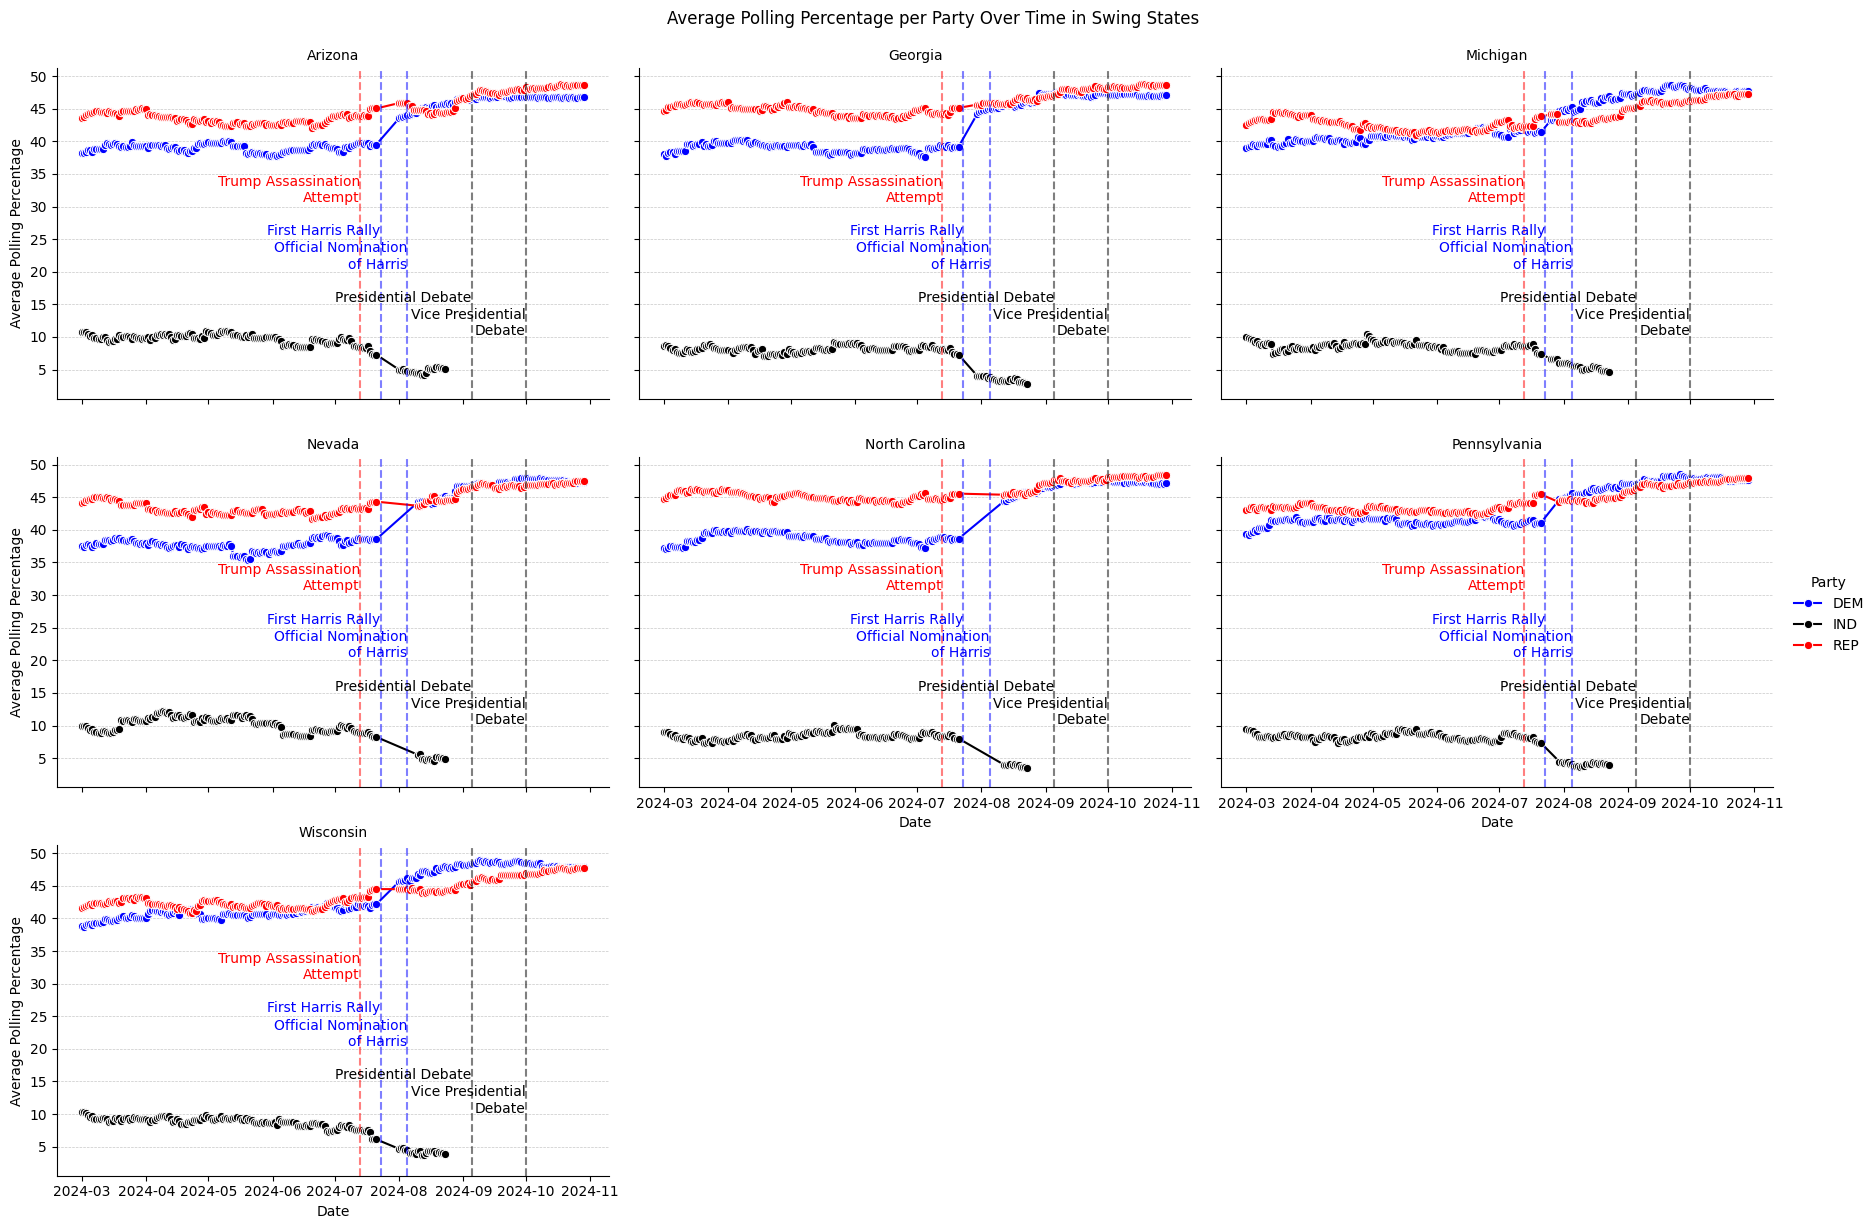

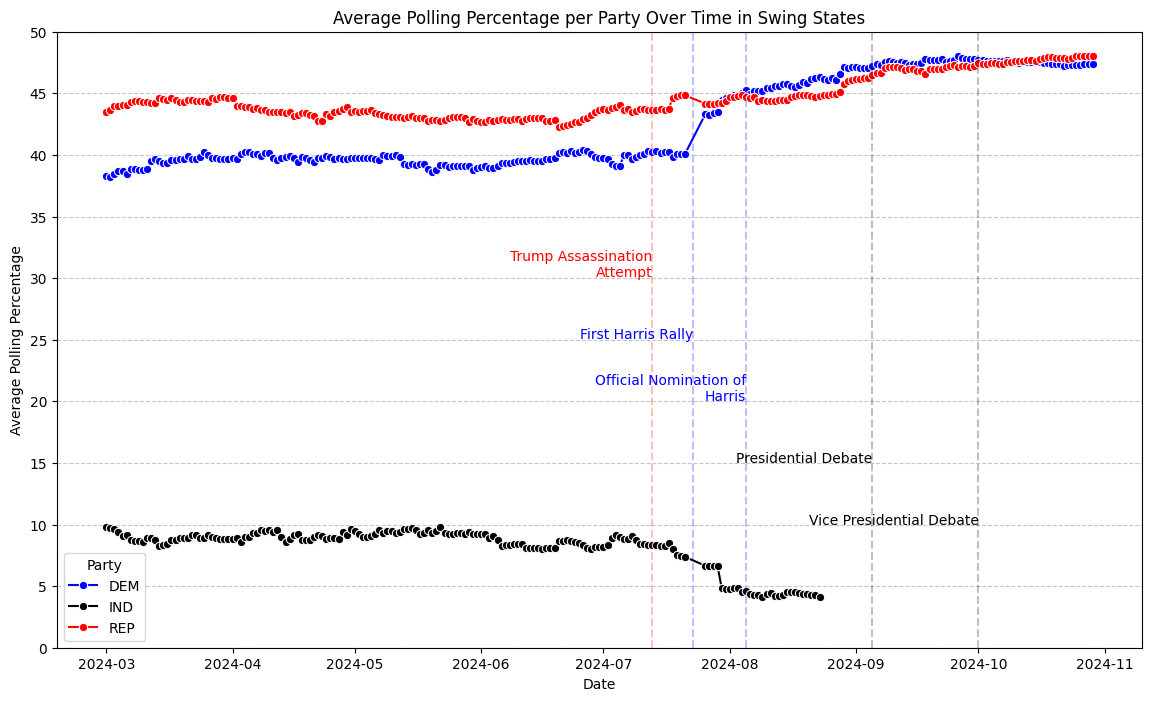

Swing 24 dtypes:
cycle                                   int64
date                           datetime64[ns]
state                                  object
party                                  object
candidate                              object
pct_estimate                          float64
pct_3rd_party                         float64
pct_opponent                          float64
lead                                  float64
days_until_election                     int64
momentum_candidate                    float64
momentum_opponent                     float64
momentum                              float64
is_incumbent_president                   bool
is_incumbent_vice_president              bool
is_incumbent_party                       bool
party_DEM                                bool
party_REP                                bool
dtype: object

Swing until 20 dtypes:
cycle                                   int64
date                           datetime64[ns]
state                    

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e


Maximum correct winners by state:
state
Arizona           1
Georgia           1
Michigan          1
Nevada            1
North Carolina    0
Pennsylvania      1
Wisconsin         1
Name: correct_winner, dtype: int64

Minimum MAE by state:
state
Arizona           2.184046
Georgia           1.416059
Michigan          1.731490
Nevada            3.360819
North Carolina    0.674078
Pennsylvania      1.088153
Wisconsin         1.917802
Name: MAE, dtype: float64

Best models by state:
{'Arizona': 'RandomForest', 'Georgia': 'XGBoost', 'Michigan': 'RandomForest', 'Nevada': 'ElasticNet', 'North Carolina': 'ElasticNet', 'Pennsylvania': 'XGBoost', 'Wisconsin': 'XGBoost'}

2024 Vote Share Predictions:
party                 DEM        REP
state                               
Arizona         48.244605  49.242076
Georgia         49.472835  49.472847
Michigan        50.387713  49.241665
Nevada          48.910010  48.813020
North Carolina  49.427055  49.093490
Pennsylvania    49.851844  49.851902
Wiscon

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import numpy as np

# --- Data Sourcing and Initial Filtering ---
# reading csv files
polls_24 = pd.read_csv('/content/presidential_general_averages.csv')
polls_20 = pd.read_csv('/content/presidential_poll_averages_2020.csv')
polls_until_16 = pd.read_csv('/content/pres_pollaverages_1968-2016.csv')

# filtering and concatenating DataFrames
polls_24 = polls_24[polls_24['cycle'] == 2024]
polls_until_20 = pd.concat([polls_20, polls_until_16], ignore_index=True)

# making sure dates are in datetime format
polls_24['date'] = pd.to_datetime(polls_24['date'], format='%Y-%m-%d')
polls_until_20['modeldate'] = pd.to_datetime(polls_until_20['modeldate'])

# keeping only the columns of interest
polls_until_20 = polls_until_20[['cycle', 'state', 'modeldate', 'candidate_name',
 'pct_estimate', 'pct_trend_adjusted']]

# importing result data
results_until_20 = pd.read_csv('/content/result.csv', sep=';')
results_until_20 = results_until_20[['cycle', 'state', 'party', 'candidate',
 'vote_share']]

# implementing cycle restriction (starting from 2000)
start_cycle = 2000
polls_until_20 = polls_until_20[polls_until_20['cycle'] >= start_cycle]

# --- State Definitions and Subsetting ---
# Defining state lists
swing_states = ['Pennsylvania', 'Wisconsin', 'Michigan', 'Georgia', 'North Carolina',
 'Arizona', 'Nevada']
blue_states = ['District of Columbia', 'Vermont', 'Massachusetts', 'Maryland', 'Hawaii',
 'California', 'ME-1', 'Connecticut', 'Washington', 'Delaware', 'Rhode Island', 'New York',
 'Illinois', 'New Jersey', 'Oregon', 'Colorado', 'Maine', 'New Mexico',
 'Virginia', 'New Hampshire', 'NE-2', 'Minnesota']
red_states = ['Wyoming', 'West Virginia', 'Oklahoma', 'North Dakota', 'Idaho', 'South Dakota',
 'Arkansas', 'Kentucky', 'NE-3', 'Alabama', 'Tennessee', 'Utah', 'Louisiana',
 'Nebraska', 'Mississippi', 'Montana', 'NE-1', 'Indiana', 'Kansas', 'Missouri', 'South Carolina',
 'Alaska', 'Ohio', 'Iowa', 'Texas', 'ME-2', 'Florida']

# Defining swing state subset of the poll data
swing_until_20 = polls_until_20[polls_until_20['state'].isin(swing_states)]
swing_24 = polls_24[polls_24['state'].isin(swing_states)]

# --- Exploratory Data Analysis and Data Cleaning ---
# checking for missing values in swing_24 and swing_until_20
print("Missing values in swing_24:")
print(swing_24.isnull().sum())
print("\nMissing values in swing_until_20:")
print(swing_until_20.isnull().sum())

print('\n2024 data:')
print(swing_24['date'].min()) # earliest polling date
print(swing_24['date'].max()) # latest polling date
print(swing_24['state'].unique().tolist()) # distinct states
print(swing_24['party'].unique().tolist()) # distinct parties
print(swing_24['candidate'].unique().tolist()) # distinct candidates

print('\nHistorical data:')
print(swing_until_20['modeldate'].min())
print(swing_until_20['modeldate'].max())
print(swing_until_20['state'].unique().tolist())
print(swing_until_20['candidate_name'].unique().tolist())

# Only keep rows where candidate_name does not start with 'Convention Bounce'
swing_until_20 = swing_until_20[~swing_until_20['candidate_name'].str.startswith('Convention Bounce')]

#Checking correlation between the percentages
adj_corr_swing = swing_until_20['pct_estimate'].corr(swing_until_20['pct_trend_adjusted'])
print('Correlation between estimated and trend-adjusted percentage in swing states: ' + str(adj_corr_swing))

# Calculate the mean difference between pct_estimate and pct_trend_adjusted, grouping by date, state, and party
mean_diff = (swing_until_20['pct_estimate'] - swing_until_20['pct_trend_adjusted']).mean()
print('Mean difference between estimated and trend-adjusted percentage in swing states: ' + str(mean_diff))

# Finding out how often pct_estimate and pct_trend_adjusted saw different candidates in the lead in 2020 race
swing_20 = swing_until_20[swing_until_20['cycle'] == 2020].copy()

# Create a new column to indicate if the ranking is different between pct_estimate and pct_trend_adjusted
swing_20.loc[:, 'rank_estimate'] = swing_20.groupby(['state', 'modeldate'])['pct_estimate'].rank(ascending=False)
swing_20.loc[:, 'rank_trend_adjusted'] = swing_20.groupby(['state', 'modeldate'])['pct_trend_adjusted'].rank(ascending=False)

# Rows where the rankings are different in swing states
different_rankings_swing = swing_20[swing_20['rank_estimate'] != swing_20['rank_trend_adjusted']]
print('Number of observations with differing leader: ' + str(different_rankings_swing.shape[0] / 2))
print('Last occurence: ' + str(different_rankings_swing['modeldate'].max()))

# --- Adding party column and historical result data ---
# Get unique candidate names
candidate_names = swing_until_20['candidate_name'].unique().tolist()

# Create a dictionary of candidates and their political party
party_map = {
 'Joseph R. Biden Jr.': 'DEM',
 'Donald Trump': 'REP',
 'Hillary Rodham Clinton': 'DEM',
 'Gary Johnson': 'LIB',
 'Barack Obama': 'DEM',
 'Mitt Romney': 'REP',
 'John McCain': 'REP',
 'Ralph Nader': 'IND',
 'George W. Bush': 'REP',
 'John Kerry': 'DEM',
 'Al Gore': 'DEM',
 'Pat Buchanan': 'REF',
 'Bob Dole': 'REP',
 'Bill Clinton': 'DEM',
 'H. Ross Perot': 'IND',
 'George Bush': 'REP',
 'Michael S. Dukakis': 'DEM',
 'Walter F. Mondale': 'DEM',
 'Ronald Reagan': 'REP',
 'Jimmy Carter': 'DEM',
 'John B. Anderson': 'IND',
 'Gerald R. Ford': 'REP',
 'George S. McGovern': 'DEM',
 'Barry Goldwater': 'REP',
 'Hubert Humphrey, Jr.': 'DEM',
 'Richard M. Nixon': 'REP',
 'George Wallace': 'IND',
 'Eugene McCarthy': 'IND'
}

# Create a DataFrame with candidates and their respective parties
candidate_df = pd.DataFrame(candidate_names, columns=['candidate_name'])
candidate_df['party'] = candidate_df['candidate_name'].map(party_map)

# Merge the candidate_df with swing_until_20 on 'candidate' column
swing_until_20 = swing_until_20.merge(candidate_df[['candidate_name', 'party']], on='candidate_name', how='left')

# Merging results_until_20 to swing_until_20
swing_until_20 = pd.merge(swing_until_20, results_until_20, how='left', left_on=['cycle', 'state', 'party', 'candidate_name'], right_on=['cycle', 'state', 'party', 'candidate'])

swing_until_20['vote_share'] = swing_until_20['vote_share'].str.replace(',', '.')
swing_until_20['vote_share'] = pd.to_numeric(swing_until_20['vote_share'])

# --- Aligning columns and column names ---
# Renaming columns in swing_until_20
swing_until_20.rename(columns={'modeldate': 'date'}, inplace=True)

# Keeping only relevant columns
swing_24 = swing_24[['cycle', 'date', 'state', 'party', 'candidate', 'pct_estimate']]
swing_until_20 = swing_until_20[['cycle', 'date', 'state', 'party', 'candidate', 'pct_estimate', 'vote_share']]

# Update candidate names in swing_24 dataframe
swing_24['candidate'] = swing_24['candidate'].replace({
 'Trump': 'Donald Trump',
 'Biden': 'Joseph R. Biden Jr.',
 'Harris': 'Kamala Harris',
 'Kennedy': 'Robert F. Kennedy'
})

# --- Overview over the 2024 campaign (Faceted Plot) ---
# Ensure the date column is in datetime format
swing_24['date'] = pd.to_datetime(swing_24['date'])

# Group by date, state, and party, then average the pct_estimate
swing_24_grouped = swing_24.groupby(['date', 'state', 'party'])['pct_estimate'].mean().reset_index()

# Create the faceted line charts
g = sns.FacetGrid(swing_24_grouped, col='state', col_wrap=3, height=4, aspect=1.5, sharey=True)
g.map_dataframe(sns.lineplot, x='date', y='pct_estimate', hue='party', marker='o', palette={'REP': 'red', 'DEM': 'blue', 'IND': 'black'})

# Add vertical lines for significant events
for ax in g.axes.flat:
    ax.axvline(pd.to_datetime('2024-07-13'), color='red', linestyle='--', alpha=0.5)
    ax.axvline(pd.to_datetime('2024-08-05'), color='blue', linestyle='--', alpha=0.5)
    ax.axvline(pd.to_datetime('2024-07-23'), color='blue', linestyle='--', alpha=0.5)
    ax.axvline(pd.to_datetime('2024-09-05'), color='black', linestyle='--', alpha=0.5)
    ax.axvline(pd.to_datetime('2024-10-01'), color='black', linestyle='--', alpha=0.5)
    ax.text(pd.to_datetime('2024-07-13'), ax.get_ylim()[1] * 0.6, 'Trump Assassination\nAttempt', color='red', ha='right')
    ax.text(pd.to_datetime('2024-07-23'), ax.get_ylim()[1] * 0.5, 'First Harris Rally', color='blue', ha='right')
    ax.text(pd.to_datetime('2024-08-05'), ax.get_ylim()[1] * 0.4, 'Official Nomination\nof Harris', color='blue', ha='right')
    ax.text(pd.to_datetime('2024-09-05'), ax.get_ylim()[1] * 0.3, 'Presidential Debate', color='black', ha='right')
    ax.text(pd.to_datetime('2024-10-01'), ax.get_ylim()[1] * 0.2, 'Vice Presidential\nDebate', color='black', ha='right')
    ax.yaxis.set_major_locator(plt.MultipleLocator(5)) # Add horizontal gridlines at values divisible by 5
    ax.grid(True, which='major', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

# Adjust the legend
g.add_legend(title='Party')

# Set titles and labels
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Date", "Average Polling Percentage")
g.fig.suptitle('Average Polling Percentage per Party Over Time in Swing States', y=1.02)
plt.show()

# --- Overview over the 2024 campaign (Single Line Chart) ---
# Ensure the date column is in datetime format
swing_24['date'] = pd.to_datetime(swing_24['date'])

# Group by date and party, then average the pct_estimate
swing_24_grouped = swing_24.groupby(['date', 'party'])['pct_estimate'].mean().reset_index()

# Create the line chart
plt.figure(figsize=(14, 8))
sns.lineplot(data=swing_24_grouped, x='date', y='pct_estimate', hue='party', marker='o', palette={'REP': 'red', 'DEM': 'blue', 'IND': 'black'})

# Add vertical lines for significant events
plt.axvline(pd.to_datetime('2024-07-13'), color='red', linestyle='--', alpha=0.25)
plt.axvline(pd.to_datetime('2024-08-05'), color='blue', linestyle='--', alpha=0.25)
plt.axvline(pd.to_datetime('2024-07-23'), color='blue', linestyle='--', alpha=0.25)
plt.axvline(pd.to_datetime('2024-09-05'), color='black', linestyle='--', alpha=0.25)
plt.axvline(pd.to_datetime('2024-10-01'), color='black', linestyle='--', alpha=0.25)

# Add text annotations for significant events
plt.text(pd.to_datetime('2024-07-13'), plt.ylim()[1] * 0.6, 'Trump Assassination\nAttempt', color='red', ha='right')
plt.text(pd.to_datetime('2024-07-23'), plt.ylim()[1] * 0.5, 'First Harris Rally', color='blue', ha='right')
plt.text(pd.to_datetime('2024-08-05'), plt.ylim()[1] * 0.4, 'Official Nomination of\nHarris', color='blue', ha='right')
plt.text(pd.to_datetime('2024-09-05'), plt.ylim()[1] * 0.3, 'Presidential Debate', color='black', ha='right')
plt.text(pd.to_datetime('2024-10-01'), plt.ylim()[1] * 0.2, 'Vice Presidential Debate', color='black', ha='right')

# Add horizontal gridlines at values dividable by 5
plt.yticks(range(0, 51, 5))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Limit the y-axis range to 50
plt.ylim(0, 50)

# Adjust the legend
plt.legend(title='Party')

# Set titles and labels
plt.title('Average Polling Percentage per Party Over Time in Swing States')
plt.xlabel('Date')
plt.ylabel('Average Polling Percentage')
plt.show()

# --- Feature Engineering ---
# Opponent-related features
# Adding the percentage of 3rd party candidates
swing_24['pct_3rd_party'] = swing_24.groupby(['cycle', 'date', 'state'])['pct_estimate'].transform(
    lambda x: x[~swing_24['party'].isin(['DEM', 'REP'])].sum()
)
swing_until_20['pct_3rd_party'] = swing_until_20.groupby(['cycle', 'date', 'state'])['pct_estimate'].transform(
    lambda x: x[~swing_until_20['party'].isin(['DEM', 'REP'])].sum()
)

# Removing observations of candidates who are not Democrats and Republicans
swing_24 = swing_24[swing_24['party'].isin(['DEM', 'REP'])]
swing_until_20 = swing_until_20[swing_until_20['party'].isin(['DEM', 'REP'])]

# Adding the percentage of the opponent
swing_24['pct_opponent'] = swing_24.apply(
    lambda row: swing_24[(swing_24['date'] == row['date']) & (swing_24['state'] == row['state']) & (swing_24['party'] != row['party'])]['pct_estimate'].sum(),
    axis=1
)
swing_until_20['pct_opponent'] = swing_until_20.apply(
    lambda row: swing_until_20[(swing_until_20['date'] == row['date']) & (swing_until_20['state'] == row['state']) & (swing_until_20['party'] != row['party'])]['pct_estimate'].sum(),
    axis=1
)

# Adding the lead against the opponent
swing_24['lead'] = swing_24['pct_estimate'] - swing_24['pct_opponent']
swing_until_20['lead'] = swing_until_20['pct_estimate'] - swing_until_20['pct_opponent']

# Time-related features
# days until election
election_dates = {
    2000: pd.to_datetime('2000-11-07'),
    2004: pd.to_datetime('2004-11-02'),
    2008: pd.to_datetime('2008-11-04'),
    2012: pd.to_datetime('2012-11-06'),
    2016: pd.to_datetime('2016-11-08'),
    2020: pd.to_datetime('2020-11-03'),
    2024: pd.to_datetime('2024-11-05')
}
swing_24['days_until_election'] = (election_dates[2024] - swing_24['date']).dt.days
swing_until_20['days_until_election'] = swing_until_20.apply(
    lambda row: (election_dates.get(row['cycle']) - row['date']).days, axis=1
)

# Calculate the daily change (momentum) for each candidate
swing_24['momentum_candidate'] = swing_24.groupby(['state', 'party'])['pct_estimate'].diff()
swing_until_20['momentum_candidate'] = swing_until_20.groupby(['state', 'party'])['pct_estimate'].diff()

# Calculate the daily change (momentum) for each opponent
swing_24['momentum_opponent'] = swing_24.groupby(['state', 'party'])['pct_opponent'].diff()
swing_until_20['momentum_opponent'] = swing_until_20.groupby(['state', 'party'])['pct_opponent'].diff()

# Calculate the difference between the candidate's momentum and the opponent's momentum
swing_24['momentum'] = swing_24['momentum_candidate'] - swing_24['momentum_opponent']
swing_until_20['momentum'] = swing_until_20['momentum_candidate'] - swing_until_20['momentum_opponent']

# Candidate-related features
# Defining incumbent presidents and vice-presidents
incumbent_presidents = {
    2000: 'Bill Clinton',
    2004: 'George W. Bush',
    2008: 'George W. Bush',
    2012: 'Barack Obama',
    2016: 'Barack Obama',
    2020: 'Donald Trump',
    2024: 'Joseph R. Biden Jr.'
}
incumbent_vice_presidents = {
    2000: 'Al Gore',
    2004: 'Richard Cheney',
    2008: 'Richard Cheney',
    2012: 'Joseph R. Biden Jr.',
    2016: 'Joseph R. Biden Jr.',
    2020: 'Mike Pence',
    2024: 'Kamala Harris'
}

# Adding is_incumbent_president column
swing_until_20['is_incumbent_president'] = swing_until_20.apply(
    lambda row: row['candidate'] == incumbent_presidents.get(row['cycle'], ''), axis=1
)
swing_24['is_incumbent_president'] = swing_24.apply(
    lambda row: row['candidate'] == incumbent_presidents.get(row['cycle'], ''), axis=1
)

# Adding is_incumbent_vice_president column
swing_until_20['is_incumbent_vice_president'] = swing_until_20.apply(
    lambda row: row['candidate'] == incumbent_vice_presidents.get(row['cycle'], ''), axis=1
)
swing_24['is_incumbent_vice_president'] = swing_24.apply(
    lambda row: row['candidate'] == incumbent_vice_presidents.get(row['cycle'], ''), axis=1
)

# define incumbent party for each election
incumbent_party = {
    2000: 'DEM',
    2004: 'REP',
    2008: 'REP',
    2012: 'DEM',
    2016: 'DEM',
    2020: 'REP',
    2024: 'DEM'
}

# define is_incumbent_party
swing_until_20['is_incumbent_party'] = swing_until_20.apply(
    lambda row: row['party'] == incumbent_party.get(row['cycle'], ''), axis=1
)
swing_24['is_incumbent_party'] = swing_24.apply(
    lambda row: row['party'] == incumbent_party.get(row['cycle'], ''), axis=1
)

# Create duplicate party column for one-hot encoding
swing_24['party_dummy'] = swing_24['party']
swing_until_20['party_dummy'] = swing_until_20['party']

# One-hot encode the duplicate party column in swing_24 and swing_until_20
swing_24 = pd.get_dummies(swing_24, columns=['party_dummy'], prefix='party')
swing_until_20 = pd.get_dummies(swing_until_20, columns=['party_dummy'], prefix='party')

# --- Final Preparations ---
# Dropping missing values
swing_24 = swing_24.dropna()
swing_until_20 = swing_until_20.dropna()

# Printing out the formats of all columns in swing_24 and swing_until_20
print("Swing 24 dtypes:")
print(swing_24.dtypes)
print("\nSwing until 20 dtypes:")
print(swing_until_20.dtypes)

# Getting description of distributions in swing_until_20
print("\nHistorical data description:")
print(swing_until_20[['pct_estimate', 'lead', 'pct_3rd_party', 'momentum', 'vote_share']].describe())

# Getting description of distributions in swing_24
print("\n2024 data description:")
print(swing_24[['pct_estimate', 'lead', 'pct_3rd_party','momentum']].describe())

# --- Choosing the Models (Definitions) ---
# Define features and models
features = ['pct_estimate', 'pct_opponent', 'pct_3rd_party', 'lead', 'days_until_election', 'momentum_candidate', 'momentum_opponent', 'momentum', 'is_incumbent_president', 'is_incumbent_vice_president', 'is_incumbent_party', 'party_DEM', 'party_REP']
target = 'vote_share'

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'MLPRegressor': MLPRegressor(random_state=42, max_iter=1000),
    'SVR': SVR(kernel='linear'),
    'XGBoost': xgb.XGBRegressor(random_state=42)
}

# --- Training the models (Cross-Validation) ---
# Initialize a list to store results
results_list = []

# Define the election cycles
cycles = [2016, 2020]

# Define the weight function (using a typical starting k value)
def compute_weight(days_until_election, k):
    return np.exp(-k * days_until_election)

# Outer loop: test_cycles starting 2004
for i in range(1, len(cycles)):
    test_cycle = cycles[i]
    train_cycles = cycles[:i] # All cycles before the test_cycle

    # Middle loop: states
    for state in swing_states:
        # Filter data for the state you're analyzing
        data_state = swing_until_20[swing_until_20['state'] == state].copy()

        # Add weights to the data
        data_state['weight'] = compute_weight(data_state['days_until_election'], k=0.1)

        # Split data into training and testing sets based on election cycles
        train_data = data_state[data_state['cycle'].isin(train_cycles)]
        test_data = data_state[data_state['cycle'] == test_cycle]

        # Define feature and target variables
        X_train = train_data[features]
        y_train = train_data[target]
        X_test = test_data[features]
        y_test = test_data[target]

        # Inner loop: Models
        for model_name, model in models.items():
            # Train the model with sample_weight for models that support it
            if model_name == 'MLPRegressor':
                # MLPRegressor doesn't support sample_weight
                model.fit(X_train, y_train)
            else:
                # Other models support sample_weight
                model.fit(X_train, y_train, sample_weight=train_data['weight'])

            # Predict on test data
            test_data_copy = test_data.copy()
            test_data_copy.loc[:, f'predicted_{model_name}'] = model.predict(X_test)

            # Aggregate predictions using weights
            aggregated_predictions = test_data_copy.groupby('party').apply(
                lambda df: np.average(df[f'predicted_{model_name}'], weights=df['weight']), include_groups=False
            ).reset_index(name='aggregated_prediction')

            # Get actual vote shares for comparison
            actual_vote_shares = test_data_copy.groupby('party')['vote_share'].mean().reset_index()
            comparison = pd.merge(aggregated_predictions, actual_vote_shares, on='party')
            comparison.rename(columns={'vote_share': 'actual_vote_share'}, inplace=True)

            # Calculate Mean Absolute Error
            mae = mean_absolute_error(comparison['actual_vote_share'], comparison['aggregated_prediction'])

            # Determine winner
            predicted_winner = comparison.loc[comparison['aggregated_prediction'].idxmax(), 'party']
            actual_winner = comparison.loc[comparison['actual_vote_share'].idxmax(), 'party']
            correct_winner = 1 if predicted_winner == actual_winner else 0

            # Store results
            results_list.append({
                'state': state,
                'test_cycle': test_cycle,
                'model_name': model_name,
                'MAE': mae,
                'correct_winner': correct_winner
            })

# --- Evaluation and Best Model Selection ---
# After the loop, create a DataFrame from the results list
results_df = pd.DataFrame(results_list)

# Get the sum of correct_winner and the average MAE for every combination of state and model_name
aggregated_evaluation = results_df.groupby(['state', 'model_name']).agg({
    'correct_winner': 'sum',
    'MAE': 'mean'
}).reset_index()

# Display the maximum amount of correct winners and the minimum MAE the same model has in each state
print("\nMaximum correct winners by state:")
print(aggregated_evaluation.groupby('state')['correct_winner'].max())
print("\nMinimum MAE by state:")
print(aggregated_evaluation.groupby('state')['MAE'].min())

# Sort the models for each state by correct_winner (descending) and then by MAE (ascending)
sorted_evaluation = aggregated_evaluation.sort_values(by=['state', 'correct_winner', 'MAE'], ascending=[True, False, True])

# Create a dictionary to store the best model for each state
best_models = {}

# Iterate over each state and get the top model
for state in sorted_evaluation['state'].unique():
    top_model = sorted_evaluation[sorted_evaluation['state'] == state].iloc[0]
    best_models[state] = top_model['model_name']

print("\nBest models by state:")
print(best_models)

# --- Predicting the Swing States ---
# Initialize a list to store predictions
predictions_list = []
for state, model_name in best_models.items():
    # Filter the data for the specific state
    state_data_train = swing_until_20[swing_until_20['state'] == state].copy() # Data from 2000 to 2020
    state_data_test = swing_24[swing_24['state'] == state].copy() # Data for 2024

    # Add weights to the training data
    state_data_train['weight'] = compute_weight(state_data_train['days_until_election'], k=0.1)

    # Add weights to the test data
    state_data_test['weight'] = compute_weight(state_data_test['days_until_election'], k=0.1)

    # Define features (Using the features defined for training)
    features = ['pct_estimate', 'pct_opponent', 'pct_3rd_party', 'lead', 'days_until_election', 'momentum_candidate', 'momentum_opponent', 'momentum', 'is_incumbent_president', 'is_incumbent_vice_president', 'is_incumbent_party', 'party_DEM', 'party_REP']
    target = 'vote_share'

    # Split features and target variable
    X_train = state_data_train[features]
    y_train = state_data_train[target]
    X_test = state_data_test[features]

    # Initialize and train the best model
    model = models[model_name]

    # Train with sample_weight for models that support it
    if model_name == 'MLPRegressor':
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=state_data_train['weight'])

    # Predict on test data
    state_data_test_copy = state_data_test.copy()
    state_data_test_copy.loc[:, f'predicted_{model_name}'] = model.predict(X_test)

    # Aggregate predictions using weights
    aggregated_predictions = state_data_test_copy.groupby('party').apply(
        lambda df: np.average(df[f'predicted_{model_name}'], weights=df['weight']), include_groups=False
    ).reset_index(name='predicted_vote_share')
    aggregated_predictions['state'] = state
    predictions_list.extend(aggregated_predictions.to_dict('records'))

# Convert predictions list to DataFrame
predictions_df = pd.DataFrame(predictions_list)

# Add a rank to predictions_df for each state based on the order of predicted_vote_share
predictions_df['rank'] = predictions_df.groupby('state')['predicted_vote_share'].rank(ascending=False)

# Create a pivot table indexed by state
predictions_pivot = predictions_df.pivot(index='state', columns='party', values='predicted_vote_share')

# Display predictions
print("\n2024 Vote Share Predictions:")
print(predictions_pivot)

# --- Final Electoral College Tally ---
# Define the number of electoral votes per state for the 2024 US-Presidential elections
electoral_votes = {
    'Alabama': 9, 'Alaska': 3, 'Arizona': 11, 'Arkansas': 6, 'California': 54,
    'Colorado': 10, 'Connecticut': 7,
    'Delaware': 3, 'District of Columbia': 3, 'Florida': 30, 'Georgia': 16, 'Hawaii': 4,
    'Idaho': 4, 'Illinois': 19,
    'Indiana': 11, 'Iowa': 6, 'Kansas': 6, 'Kentucky': 8, 'Louisiana': 8, 'Maine': 2,
    'Maryland': 10, 'Massachusetts': 11,
    'Michigan': 15, 'Minnesota': 10, 'Mississippi': 6, 'Missouri': 10, 'Montana': 4,
    'Nebraska': 2, 'Nevada': 6,
    'New Hampshire': 4, 'New Jersey': 14, 'New Mexico': 5, 'New York': 28, 'North Carolina': 16,
    'North Dakota': 3,
    'Ohio': 17, 'Oklahoma': 7, 'Oregon': 8, 'Pennsylvania': 19, 'Rhode Island': 4,
    'South Carolina': 9, 'South Dakota': 3,
    'Tennessee': 11, 'Texas': 40, 'Utah': 6, 'Vermont': 3, 'Virginia': 13, 'Washington': 12, 'West Virginia': 4,
    'Wisconsin': 10, 'Wyoming': 3
}
# Create a DataFrame from the dictionary
electoral_votes_df = pd.DataFrame(electoral_votes.items(), columns=['state', 'electoral_votes'])

# Extract states from predictions_df where party is DEM and rank is 1
additional_blue_states = predictions_df[(predictions_df['party'] == 'DEM') & (predictions_df['rank'] == 1)].state.tolist()

# Extract states from predictions_df where party is REP and rank is 1
additional_red_states = predictions_df[(predictions_df['party'] == 'REP') & (predictions_df['rank'] == 1)].state.tolist()

# Combine blue_states and additional_blue_states into a single list
harris = list(set(blue_states + additional_blue_states))
trump = list(set(red_states + additional_red_states))

# Filter the electoral votes for states in each candidate's list
harris_electoral_votes = electoral_votes_df[electoral_votes_df['state'].isin(harris)]
trump_electoral_votes = electoral_votes_df[electoral_votes_df['state'].isin(trump)]

# Sum the electoral votes
sum_harris_electoral_votes = harris_electoral_votes['electoral_votes'].sum()
sum_trump_electoral_votes = trump_electoral_votes['electoral_votes'].sum()

print(f"\nAccording to the predictions: Kamala Harris (DEM) wins with {sum_harris_electoral_votes} electoral votes and Donald Trump (REP) wins with {sum_trump_electoral_votes} electoral votes.")

Missing values in swing_24:
candidate                0
date                     0
pct_trend_adjusted    4394
state                    0
cycle                    0
party                    0
pct_estimate             0
hi                       0
lo                       0
dtype: int64

Missing values in swing_until_20:
cycle                 0
state                 0
modeldate             0
candidate_name        0
pct_estimate          0
pct_trend_adjusted    0
dtype: int64

2024 data:
2024-03-01 00:00:00
2024-10-29 00:00:00
['Arizona', 'Georgia', 'Michigan', 'Nevada', 'North Carolina', 'Pennsylvania', 'Wisconsin']
['REP', 'DEM', 'IND']
['Trump', 'Harris', 'Kennedy', 'Biden']

Historical data:
2016-03-03 00:00:00
2020-11-03 00:00:00
['Wisconsin', 'Pennsylvania', 'North Carolina', 'Nevada', 'Michigan', 'Georgia', 'Arizona']
['Joseph R. Biden Jr.', 'Donald Trump', 'Convention Bounce for Joseph R. Biden Jr.', 'Convention Bounce for Donald Trump', 'Hillary Rodham Clinton']
Correlation between

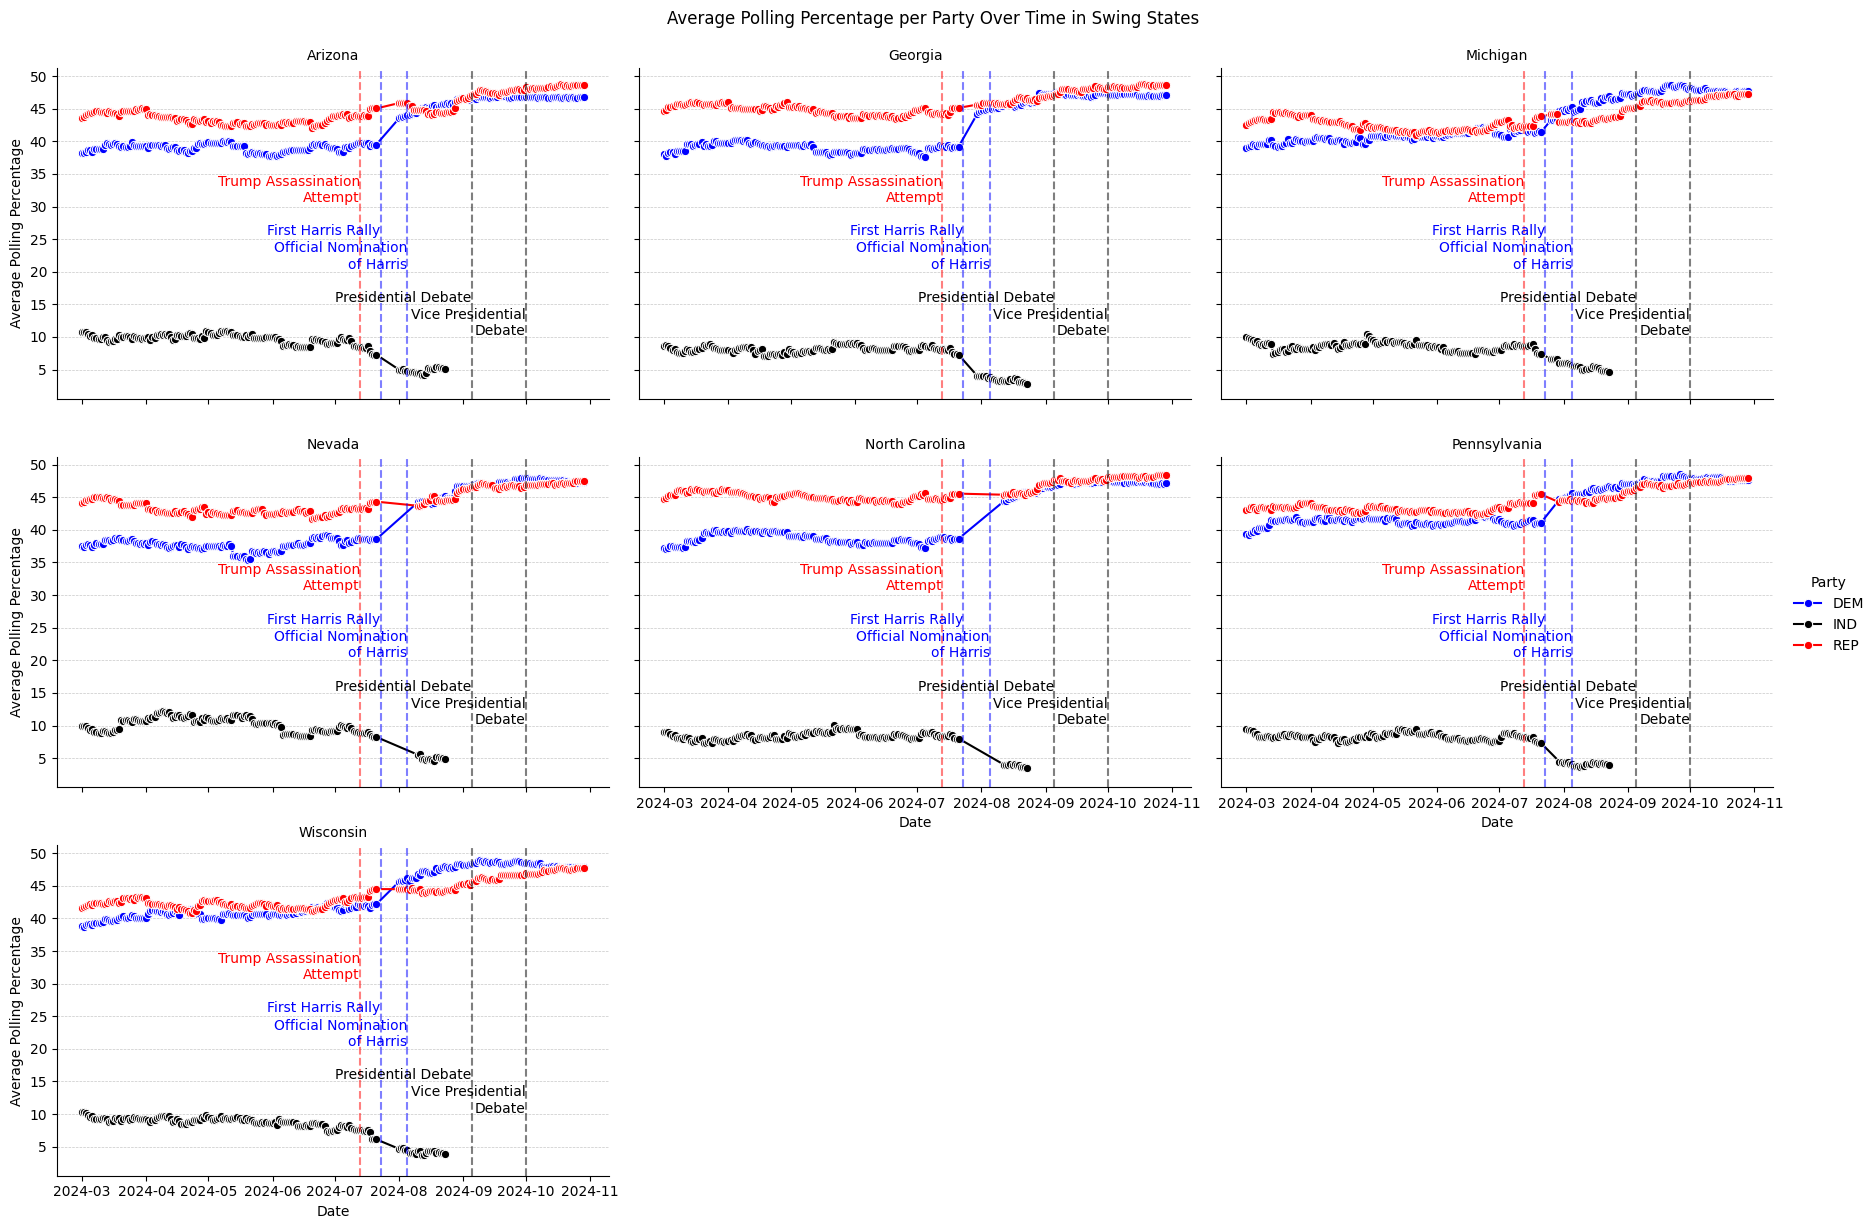

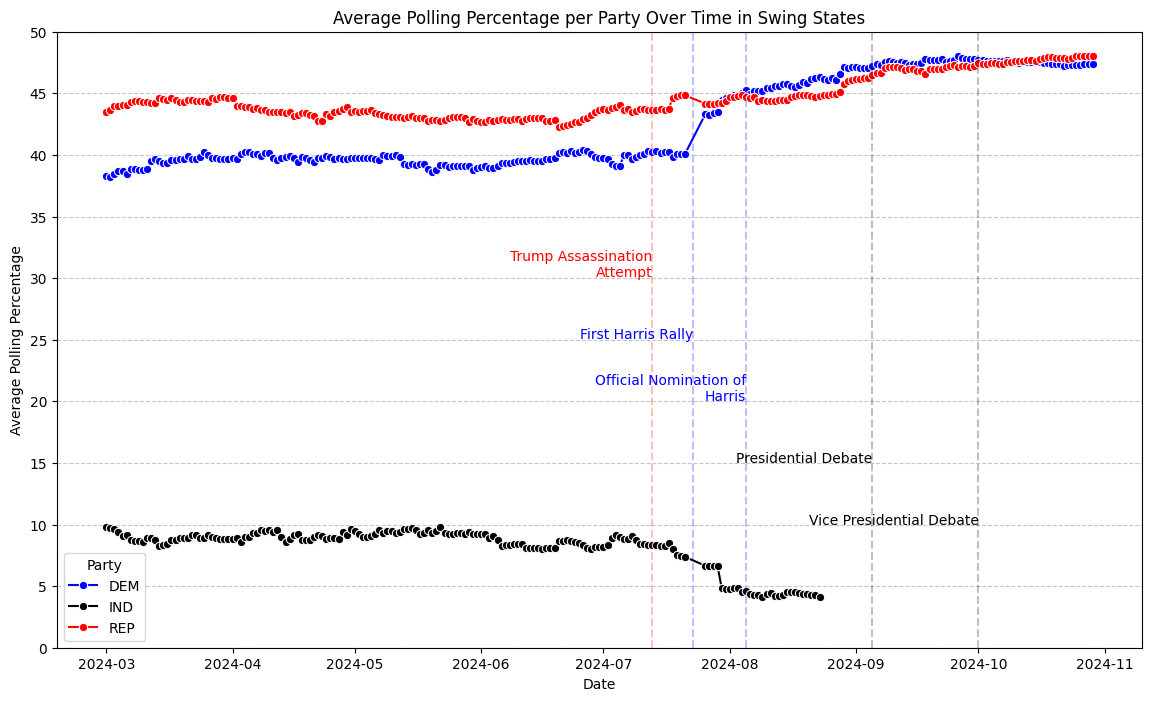

Swing 24 dtypes:
cycle                                   int64
date                           datetime64[ns]
state                                  object
party                                  object
candidate                              object
pct_estimate                          float64
pct_3rd_party                         float64
pct_opponent                          float64
lead                                  float64
days_until_election                     int64
momentum_candidate                    float64
momentum_opponent                     float64
momentum                              float64
is_incumbent_president                   bool
is_incumbent_vice_president              bool
is_incumbent_party                       bool
party_DEM                                bool
party_REP                                bool
dtype: object

Swing until 20 dtypes:
cycle                                   int64
date                           datetime64[ns]
state                    

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e


Maximum correct winners by state:
state
Arizona           1
Georgia           1
Michigan          1
Nevada            1
North Carolina    0
Pennsylvania      1
Wisconsin         1
Name: correct_winner, dtype: int64

Minimum MAE by state:
state
Arizona           2.184046
Georgia           1.416059
Michigan          1.731490
Nevada            3.360819
North Carolina    0.674078
Pennsylvania      1.088153
Wisconsin         1.917802
Name: MAE, dtype: float64

Minimum MSE by state:
state
Arizona            4.775184
Georgia            2.019099
Michigan           4.935065
Nevada            12.723770
North Carolina     0.776803
Pennsylvania       1.521197
Wisconsin          3.776277
Name: MSE, dtype: float64

Minimum RMSE by state:
state
Arizona           2.185219
Georgia           1.420950
Michigan          2.221501
Nevada            3.567039
North Carolina    0.881364
Pennsylvania      1.233368
Wisconsin         1.943264
Name: RMSE, dtype: float64
State: Arizona, Best Model: RandomForest, C

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# --- Data Sourcing and Initial Filtering ---
# reading csv files
polls_24 = pd.read_csv('/content/presidential_general_averages.csv')
polls_20 = pd.read_csv('/content/presidential_poll_averages_2020.csv')
polls_until_16 = pd.read_csv('/content/pres_pollaverages_1968-2016.csv')

# filtering and concatenating DataFrames
polls_24 = polls_24[polls_24['cycle'] == 2024]
polls_until_20 = pd.concat([polls_20, polls_until_16], ignore_index=True)

# making sure dates are in datetime format
polls_24['date'] = pd.to_datetime(polls_24['date'], format='%Y-%m-%d')
polls_until_20['modeldate'] = pd.to_datetime(polls_until_20['modeldate'])

# keeping only the columns of interest
polls_until_20 = polls_until_20[['cycle', 'state', 'modeldate', 'candidate_name',
 'pct_estimate', 'pct_trend_adjusted']]

# importing result data
results_until_20 = pd.read_csv('/content/result.csv', sep=';')
results_until_20 = results_until_20[['cycle', 'state', 'party', 'candidate',
 'vote_share']]

# implementing cycle restriction (starting from 2000)
start_cycle = 2000
polls_until_20 = polls_until_20[polls_until_20['cycle'] >= start_cycle]

# --- State Definitions and Subsetting ---
# Defining state lists
swing_states = ['Pennsylvania', 'Wisconsin', 'Michigan', 'Georgia', 'North Carolina',
 'Arizona', 'Nevada']
blue_states = ['District of Columbia', 'Vermont', 'Massachusetts', 'Maryland', 'Hawaii',
 'California', 'ME-1', 'Connecticut', 'Washington', 'Delaware', 'Rhode Island', 'New York',
 'Illinois', 'New Jersey', 'Oregon', 'Colorado', 'Maine', 'New Mexico',
 'Virginia', 'New Hampshire', 'NE-2', 'Minnesota']
red_states = ['Wyoming', 'West Virginia', 'Oklahoma', 'North Dakota', 'Idaho', 'South Dakota',
 'Arkansas', 'Kentucky', 'NE-3', 'Alabama', 'Tennessee', 'Utah', 'Louisiana',
 'Nebraska', 'Mississippi', 'Montana', 'NE-1', 'Indiana', 'Kansas', 'Missouri', 'South Carolina',
 'Alaska', 'Ohio', 'Iowa', 'Texas', 'ME-2', 'Florida']

# Defining swing state subset of the poll data
swing_until_20 = polls_until_20[polls_until_20['state'].isin(swing_states)]
swing_24 = polls_24[polls_24['state'].isin(swing_states)]

# --- Exploratory Data Analysis and Data Cleaning ---
# checking for missing values in swing_24 and swing_until_20
print("Missing values in swing_24:")
print(swing_24.isnull().sum())
print("\nMissing values in swing_until_20:")
print(swing_until_20.isnull().sum())

print('\n2024 data:')
print(swing_24['date'].min()) # earliest polling date
print(swing_24['date'].max()) # latest polling date
print(swing_24['state'].unique().tolist()) # distinct states
print(swing_24['party'].unique().tolist()) # distinct parties
print(swing_24['candidate'].unique().tolist()) # distinct candidates

print('\nHistorical data:')
print(swing_until_20['modeldate'].min())
print(swing_until_20['modeldate'].max())
print(swing_until_20['state'].unique().tolist())
print(swing_until_20['candidate_name'].unique().tolist())

# Only keep rows where candidate_name does not start with 'Convention Bounce'
swing_until_20 = swing_until_20[~swing_until_20['candidate_name'].str.startswith('Convention Bounce')]

#Checking correlation between the percentages
adj_corr_swing = swing_until_20['pct_estimate'].corr(swing_until_20['pct_trend_adjusted'])
print('Correlation between estimated and trend-adjusted percentage in swing states: ' + str(adj_corr_swing))

# Calculate the mean difference between pct_estimate and pct_trend_adjusted, grouping by date, state, and party
mean_diff = (swing_until_20['pct_estimate'] - swing_until_20['pct_trend_adjusted']).mean()
print('Mean difference between estimated and trend-adjusted percentage in swing states: ' + str(mean_diff))

# Finding out how often pct_estimate and pct_trend_adjusted saw different candidates in the lead in 2020 race
swing_20 = swing_until_20[swing_until_20['cycle'] == 2020].copy()

# Create a new column to indicate if the ranking is different between pct_estimate and pct_trend_adjusted
swing_20.loc[:, 'rank_estimate'] = swing_20.groupby(['state', 'modeldate'])['pct_estimate'].rank(ascending=False)
swing_20.loc[:, 'rank_trend_adjusted'] = swing_20.groupby(['state', 'modeldate'])['pct_trend_adjusted'].rank(ascending=False)

# Rows where the rankings are different in swing states
different_rankings_swing = swing_20[swing_20['rank_estimate'] != swing_20['rank_trend_adjusted']]
print('Number of observations with differing leader: ' + str(different_rankings_swing.shape[0] / 2))
print('Last occurence: ' + str(different_rankings_swing['modeldate'].max()))

# --- Adding party column and historical result data ---
# Get unique candidate names
candidate_names = swing_until_20['candidate_name'].unique().tolist()

# Create a dictionary of candidates and their political party
party_map = {
 'Joseph R. Biden Jr.': 'DEM',
 'Donald Trump': 'REP',
 'Hillary Rodham Clinton': 'DEM',
 'Gary Johnson': 'LIB',
 'Barack Obama': 'DEM',
 'Mitt Romney': 'REP',
 'John McCain': 'REP',
 'Ralph Nader': 'IND',
 'George W. Bush': 'REP',
 'John Kerry': 'DEM',
 'Al Gore': 'DEM',
 'Pat Buchanan': 'REF',
 'Bob Dole': 'REP',
 'Bill Clinton': 'DEM',
 'H. Ross Perot': 'IND',
 'George Bush': 'REP',
 'Michael S. Dukakis': 'DEM',
 'Walter F. Mondale': 'DEM',
 'Ronald Reagan': 'REP',
 'Jimmy Carter': 'DEM',
 'John B. Anderson': 'IND',
 'Gerald R. Ford': 'REP',
 'George S. McGovern': 'DEM',
 'Barry Goldwater': 'REP',
 'Hubert Humphrey, Jr.': 'DEM',
 'Richard M. Nixon': 'REP',
 'George Wallace': 'IND',
 'Eugene McCarthy': 'IND'
}

# Create a DataFrame with candidates and their respective parties
candidate_df = pd.DataFrame(candidate_names, columns=['candidate_name'])
candidate_df['party'] = candidate_df['candidate_name'].map(party_map)

# Merge the candidate_df with swing_until_20 on 'candidate' column
swing_until_20 = swing_until_20.merge(candidate_df[['candidate_name', 'party']], on='candidate_name', how='left')

# Merging results_until_20 to swing_until_20
swing_until_20 = pd.merge(swing_until_20, results_until_20, how='left', left_on=['cycle', 'state', 'party', 'candidate_name'], right_on=['cycle', 'state', 'party', 'candidate'])

swing_until_20['vote_share'] = swing_until_20['vote_share'].str.replace(',', '.')
swing_until_20['vote_share'] = pd.to_numeric(swing_until_20['vote_share'])

# --- Aligning columns and column names ---
# Renaming columns in swing_until_20
swing_until_20.rename(columns={'modeldate': 'date'}, inplace=True)

# Keeping only relevant columns
swing_24 = swing_24[['cycle', 'date', 'state', 'party', 'candidate', 'pct_estimate']]
swing_until_20 = swing_until_20[['cycle', 'date', 'state', 'party', 'candidate', 'pct_estimate', 'vote_share']]

# Update candidate names in swing_24 dataframe
swing_24['candidate'] = swing_24['candidate'].replace({
 'Trump': 'Donald Trump',
 'Biden': 'Joseph R. Biden Jr.',
 'Harris': 'Kamala Harris',
 'Kennedy': 'Robert F. Kennedy'
})

# --- Overview over the 2024 campaign (Faceted Plot) ---
# Ensure the date column is in datetime format
swing_24['date'] = pd.to_datetime(swing_24['date'])

# Group by date, state, and party, then average the pct_estimate
swing_24_grouped = swing_24.groupby(['date', 'state', 'party'])['pct_estimate'].mean().reset_index()

# Create the faceted line charts
g = sns.FacetGrid(swing_24_grouped, col='state', col_wrap=3, height=4, aspect=1.5, sharey=True)
g.map_dataframe(sns.lineplot, x='date', y='pct_estimate', hue='party', marker='o', palette={'REP': 'red', 'DEM': 'blue', 'IND': 'black'})

# Add vertical lines for significant events
for ax in g.axes.flat:
    ax.axvline(pd.to_datetime('2024-07-13'), color='red', linestyle='--', alpha=0.5)
    ax.axvline(pd.to_datetime('2024-08-05'), color='blue', linestyle='--', alpha=0.5)
    ax.axvline(pd.to_datetime('2024-07-23'), color='blue', linestyle='--', alpha=0.5)
    ax.axvline(pd.to_datetime('2024-09-05'), color='black', linestyle='--', alpha=0.5)
    ax.axvline(pd.to_datetime('2024-10-01'), color='black', linestyle='--', alpha=0.5)
    ax.text(pd.to_datetime('2024-07-13'), ax.get_ylim()[1] * 0.6, 'Trump Assassination\nAttempt', color='red', ha='right')
    ax.text(pd.to_datetime('2024-07-23'), ax.get_ylim()[1] * 0.5, 'First Harris Rally', color='blue', ha='right')
    ax.text(pd.to_datetime('2024-08-05'), ax.get_ylim()[1] * 0.4, 'Official Nomination\nof Harris', color='blue', ha='right')
    ax.text(pd.to_datetime('2024-09-05'), ax.get_ylim()[1] * 0.3, 'Presidential Debate', color='black', ha='right')
    ax.text(pd.to_datetime('2024-10-01'), ax.get_ylim()[1] * 0.2, 'Vice Presidential\nDebate', color='black', ha='right')
    ax.yaxis.set_major_locator(plt.MultipleLocator(5)) # Add horizontal gridlines at values divisible by 5
    ax.grid(True, which='major', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

# Adjust the legend
g.add_legend(title='Party')

# Set titles and labels
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Date", "Average Polling Percentage")
g.fig.suptitle('Average Polling Percentage per Party Over Time in Swing States', y=1.02)
plt.show()

# --- Overview over the 2024 campaign (Single Line Chart) ---
# Ensure the date column is in datetime format
swing_24['date'] = pd.to_datetime(swing_24['date'])

# Group by date and party, then average the pct_estimate
swing_24_grouped = swing_24.groupby(['date', 'party'])['pct_estimate'].mean().reset_index()

# Create the line chart
plt.figure(figsize=(14, 8))
sns.lineplot(data=swing_24_grouped, x='date', y='pct_estimate', hue='party', marker='o', palette={'REP': 'red', 'DEM': 'blue', 'IND': 'black'})

# Add vertical lines for significant events
plt.axvline(pd.to_datetime('2024-07-13'), color='red', linestyle='--', alpha=0.25)
plt.axvline(pd.to_datetime('2024-08-05'), color='blue', linestyle='--', alpha=0.25)
plt.axvline(pd.to_datetime('2024-07-23'), color='blue', linestyle='--', alpha=0.25)
plt.axvline(pd.to_datetime('2024-09-05'), color='black', linestyle='--', alpha=0.25)
plt.axvline(pd.to_datetime('2024-10-01'), color='black', linestyle='--', alpha=0.25)

# Add text annotations for significant events
plt.text(pd.to_datetime('2024-07-13'), plt.ylim()[1] * 0.6, 'Trump Assassination\nAttempt', color='red', ha='right')
plt.text(pd.to_datetime('2024-07-23'), plt.ylim()[1] * 0.5, 'First Harris Rally', color='blue', ha='right')
plt.text(pd.to_datetime('2024-08-05'), plt.ylim()[1] * 0.4, 'Official Nomination of\nHarris', color='blue', ha='right')
plt.text(pd.to_datetime('2024-09-05'), plt.ylim()[1] * 0.3, 'Presidential Debate', color='black', ha='right')
plt.text(pd.to_datetime('2024-10-01'), plt.ylim()[1] * 0.2, 'Vice Presidential Debate', color='black', ha='right')

# Add horizontal gridlines at values dividable by 5
plt.yticks(range(0, 51, 5))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Limit the y-axis range to 50
plt.ylim(0, 50)

# Adjust the legend
plt.legend(title='Party')

# Set titles and labels
plt.title('Average Polling Percentage per Party Over Time in Swing States')
plt.xlabel('Date')
plt.ylabel('Average Polling Percentage')
plt.show()

# --- Feature Engineering ---
# Opponent-related features
# Adding the percentage of 3rd party candidates
swing_24['pct_3rd_party'] = swing_24.groupby(['cycle', 'date', 'state'])['pct_estimate'].transform(
    lambda x: x[~swing_24['party'].isin(['DEM', 'REP'])].sum()
)
swing_until_20['pct_3rd_party'] = swing_until_20.groupby(['cycle', 'date', 'state'])['pct_estimate'].transform(
    lambda x: x[~swing_until_20['party'].isin(['DEM', 'REP'])].sum()
)

# Removing observations of candidates who are not Democrats and Republicans
swing_24 = swing_24[swing_24['party'].isin(['DEM', 'REP'])]
swing_until_20 = swing_until_20[swing_until_20['party'].isin(['DEM', 'REP'])]

# Adding the percentage of the opponent
swing_24['pct_opponent'] = swing_24.apply(
    lambda row: swing_24[(swing_24['date'] == row['date']) & (swing_24['state'] == row['state']) & (swing_24['party'] != row['party'])]['pct_estimate'].sum(),
    axis=1
)
swing_until_20['pct_opponent'] = swing_until_20.apply(
    lambda row: swing_until_20[(swing_until_20['date'] == row['date']) & (swing_until_20['state'] == row['state']) & (swing_until_20['party'] != row['party'])]['pct_estimate'].sum(),
    axis=1
)

# Adding the lead against the opponent
swing_24['lead'] = swing_24['pct_estimate'] - swing_24['pct_opponent']
swing_until_20['lead'] = swing_until_20['pct_estimate'] - swing_until_20['pct_opponent']

# Time-related features
# days until election
election_dates = {
    2000: pd.to_datetime('2000-11-07'),
    2004: pd.to_datetime('2004-11-02'),
    2008: pd.to_datetime('2008-11-04'),
    2012: pd.to_datetime('2012-11-06'),
    2016: pd.to_datetime('2016-11-08'),
    2020: pd.to_datetime('2020-11-03'),
    2024: pd.to_datetime('2024-11-05')
}
swing_24['days_until_election'] = (election_dates[2024] - swing_24['date']).dt.days
swing_until_20['days_until_election'] = swing_until_20.apply(
    lambda row: (election_dates.get(row['cycle']) - row['date']).days, axis=1
)

# Calculate the daily change (momentum) for each candidate
swing_24['momentum_candidate'] = swing_24.groupby(['state', 'party'])['pct_estimate'].diff()
swing_until_20['momentum_candidate'] = swing_until_20.groupby(['state', 'party'])['pct_estimate'].diff()

# Calculate the daily change (momentum) for each opponent
swing_24['momentum_opponent'] = swing_24.groupby(['state', 'party'])['pct_opponent'].diff()
swing_until_20['momentum_opponent'] = swing_until_20.groupby(['state', 'party'])['pct_opponent'].diff()

# Calculate the difference between the candidate's momentum and the opponent's momentum
swing_24['momentum'] = swing_24['momentum_candidate'] - swing_24['momentum_opponent']
swing_until_20['momentum'] = swing_until_20['momentum_candidate'] - swing_until_20['momentum_opponent']

# Candidate-related features
# Defining incumbent presidents and vice-presidents
incumbent_presidents = {
    2000: 'Bill Clinton',
    2004: 'George W. Bush',
    2008: 'George W. Bush',
    2012: 'Barack Obama',
    2016: 'Barack Obama',
    2020: 'Donald Trump',
    2024: 'Joseph R. Biden Jr.'
}
incumbent_vice_presidents = {
    2000: 'Al Gore',
    2004: 'Richard Cheney',
    2008: 'Richard Cheney',
    2012: 'Joseph R. Biden Jr.',
    2016: 'Joseph R. Biden Jr.',
    2020: 'Mike Pence',
    2024: 'Kamala Harris'
}

# Adding is_incumbent_president column
swing_until_20['is_incumbent_president'] = swing_until_20.apply(
    lambda row: row['candidate'] == incumbent_presidents.get(row['cycle'], ''), axis=1
)
swing_24['is_incumbent_president'] = swing_24.apply(
    lambda row: row['candidate'] == incumbent_presidents.get(row['cycle'], ''), axis=1
)

# Adding is_incumbent_vice_president column
swing_until_20['is_incumbent_vice_president'] = swing_until_20.apply(
    lambda row: row['candidate'] == incumbent_vice_presidents.get(row['cycle'], ''), axis=1
)
swing_24['is_incumbent_vice_president'] = swing_24.apply(
    lambda row: row['candidate'] == incumbent_vice_presidents.get(row['cycle'], ''), axis=1
)

# define incumbent party for each election
incumbent_party = {
    2000: 'DEM',
    2004: 'REP',
    2008: 'REP',
    2012: 'DEM',
    2016: 'DEM',
    2020: 'REP',
    2024: 'DEM'
}

# define is_incumbent_party
swing_until_20['is_incumbent_party'] = swing_until_20.apply(
    lambda row: row['party'] == incumbent_party.get(row['cycle'], ''), axis=1
)
swing_24['is_incumbent_party'] = swing_24.apply(
    lambda row: row['party'] == incumbent_party.get(row['cycle'], ''), axis=1
)

# Create duplicate party column for one-hot encoding
swing_24['party_dummy'] = swing_24['party']
swing_until_20['party_dummy'] = swing_until_20['party']

# One-hot encode the duplicate party column in swing_24 and swing_until_20
swing_24 = pd.get_dummies(swing_24, columns=['party_dummy'], prefix='party')
swing_until_20 = pd.get_dummies(swing_until_20, columns=['party_dummy'], prefix='party')

# --- Final Preparations ---
# Dropping missing values
swing_24 = swing_24.dropna()
swing_until_20 = swing_until_20.dropna()

# Printing out the formats of all columns in swing_24 and swing_until_20
print("Swing 24 dtypes:")
print(swing_24.dtypes)
print("\nSwing until 20 dtypes:")
print(swing_until_20.dtypes)

# Getting description of distributions in swing_until_20
print("\nHistorical data description:")
print(swing_until_20[['pct_estimate', 'lead', 'pct_3rd_party', 'momentum', 'vote_share']].describe())

# Getting description of distributions in swing_24
print("\n2024 data description:")
print(swing_24[['pct_estimate', 'lead', 'pct_3rd_party','momentum']].describe())

# --- Choosing the Models (Definitions) ---
# Define features and models
features = ['pct_estimate', 'pct_opponent', 'pct_3rd_party', 'lead', 'days_until_election', 'momentum_candidate', 'momentum_opponent', 'momentum', 'is_incumbent_president', 'is_incumbent_vice_president', 'is_incumbent_party', 'party_DEM', 'party_REP']
target = 'vote_share'

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'MLPRegressor': MLPRegressor(random_state=42, max_iter=1000),
    'SVR': SVR(kernel='linear'),
    'XGBoost': xgb.XGBRegressor(random_state=42)
}

# --- Training the models (Cross-Validation) ---
# Initialize a list to store results
results_list = []

# Define the election cycles
cycles = [2016, 2020]

# Define the weight function (using a typical starting k value)
def compute_weight(days_until_election, k):
    return np.exp(-k * days_until_election)

# Outer loop: test_cycles starting 2004
for i in range(1, len(cycles)):
    test_cycle = cycles[i]
    train_cycles = cycles[:i] # All cycles before the test_cycle

    # Middle loop: states
    for state in swing_states:
        # Filter data for the state you're analyzing
        data_state = swing_until_20[swing_until_20['state'] == state].copy()

        # Add weights to the data
        data_state['weight'] = compute_weight(data_state['days_until_election'], k=0.1)

        # Split data into training and testing sets based on election cycles
        train_data = data_state[data_state['cycle'].isin(train_cycles)]
        test_data = data_state[data_state['cycle'] == test_cycle]

        # Define feature and target variables
        X_train = train_data[features]
        y_train = train_data[target]
        X_test = test_data[features]
        y_test = test_data[target]

        # Inner loop: Models
        for model_name, model in models.items():
            # Train the model with sample_weight for models that support it
            if model_name == 'MLPRegressor':
                # MLPRegressor doesn't support sample_weight
                model.fit(X_train, y_train)
            else:
                # Other models support sample_weight
                model.fit(X_train, y_train, sample_weight=train_data['weight'])

            # Predict on test data
            test_data_copy = test_data.copy()
            test_data_copy.loc[:, f'predicted_{model_name}'] = model.predict(X_test)

            # Aggregate predictions using weights
            aggregated_predictions = test_data_copy.groupby('party').apply(
                lambda df: np.average(df[f'predicted_{model_name}'], weights=df['weight']), include_groups=False
            ).reset_index(name='aggregated_prediction')

            # Get actual vote shares for comparison
            actual_vote_shares = test_data_copy.groupby('party')['vote_share'].mean().reset_index()
            comparison = pd.merge(aggregated_predictions, actual_vote_shares, on='party')
            comparison.rename(columns={'vote_share': 'actual_vote_share'}, inplace=True)

            # Calculate Mean Absolute Error and Mean Squared Error
            mae = mean_absolute_error(comparison['actual_vote_share'], comparison['aggregated_prediction'])
            mse = mean_squared_error(comparison['actual_vote_share'], comparison['aggregated_prediction'])

            # Determine winner
            predicted_winner = comparison.loc[comparison['aggregated_prediction'].idxmax(), 'party']
            actual_winner = comparison.loc[comparison['actual_vote_share'].idxmax(), 'party']
            correct_winner = 1 if predicted_winner == actual_winner else 0

            # Store results
            results_list.append({
                'state': state,
                'test_cycle': test_cycle,
                'model_name': model_name,
                'MAE': mae,
                'MSE': mse,
                'correct_winner': correct_winner
            })

# --- Evaluation and Best Model Selection ---
# After the loop, create a DataFrame from the results list
results_df = pd.DataFrame(results_list)

# Get the sum of correct_winner and the average MAE and MSE for every combination of state and model_name
aggregated_evaluation = results_df.groupby(['state', 'model_name']).agg({
    'correct_winner': 'sum',
    'MAE': 'mean',
    'MSE': 'mean'
}).reset_index()

# Add RMSE calculation
aggregated_evaluation['RMSE'] = np.sqrt(aggregated_evaluation['MSE'])

# Display the maximum amount of correct winners and the minimum MAE and MSE the same model has in each state
print("\nMaximum correct winners by state:")
print(aggregated_evaluation.groupby('state')['correct_winner'].max())
print("\nMinimum MAE by state:")
print(aggregated_evaluation.groupby('state')['MAE'].min())
print("\nMinimum MSE by state:")
print(aggregated_evaluation.groupby('state')['MSE'].min())
print("\nMinimum RMSE by state:")
print(aggregated_evaluation.groupby('state')['RMSE'].min())

# Sort the models for each state by correct_winner (descending) and then by MAE (ascending)
sorted_evaluation = aggregated_evaluation.sort_values(by=['state', 'correct_winner', 'MAE', 'MSE'],
                                                     ascending=[True, False, True, True])

# Create a dictionary to store the best model for each state
best_models = {}

# Iterate over each state and get the top model
for state in sorted_evaluation['state'].unique():
    top_model = sorted_evaluation[sorted_evaluation['state'] == state].iloc[0]
    best_models[state] = top_model['model_name']
    print(f"State: {state}, Best Model: {top_model['model_name']}, "
          f"Correct Winners: {top_model['correct_winner']}, "
          f"MAE: {top_model['MAE']:.4f}, MSE: {top_model['MSE']:.4f}, RMSE: {top_model['RMSE']:.4f}")

print("\nBest models by state:")
print(best_models)

# --- Predicting the Swing States ---
# Initialize a list to store predictions
predictions_list = []
for state, model_name in best_models.items():
    # Filter the data for the specific state
    state_data_train = swing_until_20[swing_until_20['state'] == state].copy() # Data from 2000 to 2020
    state_data_test = swing_24[swing_24['state'] == state].copy() # Data for 2024

    # Add weights to the training data
    state_data_train['weight'] = compute_weight(state_data_train['days_until_election'], k=0.1)

    # Add weights to the test data
    state_data_test['weight'] = compute_weight(state_data_test['days_until_election'], k=0.1)

    # Define features (Using the features defined for training)
    features = ['pct_estimate', 'pct_opponent', 'pct_3rd_party', 'lead', 'days_until_election', 'momentum_candidate', 'momentum_opponent', 'momentum', 'is_incumbent_president', 'is_incumbent_vice_president', 'is_incumbent_party', 'party_DEM', 'party_REP']
    target = 'vote_share'

    # Split features and target variable
    X_train = state_data_train[features]
    y_train = state_data_train[target]
    X_test = state_data_test[features]

    # Initialize and train the best model
    model = models[model_name]

    # Train with sample_weight for models that support it
    if model_name == 'MLPRegressor':
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=state_data_train['weight'])

    # Predict on test data
    state_data_test_copy = state_data_test.copy()
    state_data_test_copy.loc[:, f'predicted_{model_name}'] = model.predict(X_test)

    # Aggregate predictions using weights
    aggregated_predictions = state_data_test_copy.groupby('party').apply(
        lambda df: np.average(df[f'predicted_{model_name}'], weights=df['weight']), include_groups=False
    ).reset_index(name='predicted_vote_share')
    aggregated_predictions['state'] = state
    predictions_list.extend(aggregated_predictions.to_dict('records'))

# Convert predictions list to DataFrame
predictions_df = pd.DataFrame(predictions_list)

# Add a rank to predictions_df for each state based on the order of predicted_vote_share
predictions_df['rank'] = predictions_df.groupby('state')['predicted_vote_share'].rank(ascending=False)

# Create a pivot table indexed by state
predictions_pivot = predictions_df.pivot(index='state', columns='party', values='predicted_vote_share')

# Display predictions
print("\n2024 Vote Share Predictions:")
print(predictions_pivot)

# --- Final Electoral College Tally ---
# Define the number of electoral votes per state for the 2024 US-Presidential elections
electoral_votes = {
    'Alabama': 9, 'Alaska': 3, 'Arizona': 11, 'Arkansas': 6, 'California': 54,
    'Colorado': 10, 'Connecticut': 7,
    'Delaware': 3, 'District of Columbia': 3, 'Florida': 30, 'Georgia': 16, 'Hawaii': 4,
    'Idaho': 4, 'Illinois': 19,
    'Indiana': 11, 'Iowa': 6, 'Kansas': 6, 'Kentucky': 8, 'Louisiana': 8, 'Maine': 2,
    'Maryland': 10, 'Massachusetts': 11,
    'Michigan': 15, 'Minnesota': 10, 'Mississippi': 6, 'Missouri': 10, 'Montana': 4,
    'Nebraska': 2, 'Nevada': 6,
    'New Hampshire': 4, 'New Jersey': 14, 'New Mexico': 5, 'New York': 28, 'North Carolina': 16,
    'North Dakota': 3,
    'Ohio': 17, 'Oklahoma': 7, 'Oregon': 8, 'Pennsylvania': 19, 'Rhode Island': 4,
    'South Carolina': 9, 'South Dakota': 3,
    'Tennessee': 11, 'Texas': 40, 'Utah': 6, 'Vermont': 3, 'Virginia': 13, 'Washington': 12, 'West Virginia': 4,
    'Wisconsin': 10, 'Wyoming': 3
}
# Create a DataFrame from the dictionary
electoral_votes_df = pd.DataFrame(electoral_votes.items(), columns=['state', 'electoral_votes'])

# Extract states from predictions_df where party is DEM and rank is 1
additional_blue_states = predictions_df[(predictions_df['party'] == 'DEM') & (predictions_df['rank'] == 1)].state.tolist()

# Extract states from predictions_df where party is REP and rank is 1
additional_red_states = predictions_df[(predictions_df['party'] == 'REP') & (predictions_df['rank'] == 1)].state.tolist()

# Combine blue_states and additional_blue_states into a single list
harris = list(set(blue_states + additional_blue_states))
trump = list(set(red_states + additional_red_states))

# Filter the electoral votes for states in each candidate's list
harris_electoral_votes = electoral_votes_df[electoral_votes_df['state'].isin(harris)]
trump_electoral_votes = electoral_votes_df[electoral_votes_df['state'].isin(trump)]

# Sum the electoral votes
sum_harris_electoral_votes = harris_electoral_votes['electoral_votes'].sum()
sum_trump_electoral_votes = trump_electoral_votes['electoral_votes'].sum()

print(f"\nAccording to the predictions: Kamala Harris (DEM) wins with {sum_harris_electoral_votes} electoral votes and Donald Trump (REP) wins with {sum_trump_electoral_votes} electoral votes.")

CODE 2
